<a href="https://colab.research.google.com/github/cyeef/Capstone-Projects/blob/main/Rural-Health-Access/Regional_Hospital_Spatial_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The quick and easy

New Mexico needs hospital resources in rural areas.  At the county level we are predicting short-term general hospital beds per 1000 residents - the gap between capacity a county needs and the capacity it actually has indicates where state health investments should be placed.

# Problem Statement — Rural NM Hospital Access

New Mexico is the 5th largest state in the Union by land area. Rural communities
are underserved medically, clinically, and diagnostically. Many citizens — both
Native and non-Native — in rural communities must travel hours to reach the
closest health center.

The goal of this project is to use county-level structured data to identify where
financial resources can be directed to reduce medical care gaps in rural NM.

The model estimates healthcare capacity [target: physicians per capita / beds per
capita / composite capacity score — TBD] from need drivers (population, age
structure, poverty, chronic disease burden, distance to nearest medical center).
The gap between observed capacity and the capacity a county's need predicts — the
residual — serves as a provision-vs-need mismatch signal. Counties with the
largest shortfalls surface as priorities for state health investment.

## Systems Framing

The analysis is framed through System Evaluation Theory (Renger, 2022), which
treats a problem as a system of interdependent parts evaluated against its
intended outcome — here, adequate rural health access — rather than blaming any
single component. The provision-vs-need mismatch is a measurement within a
reinforcing loop: low provision makes recruitment harder, which keeps provision
low, which sustains the access gap. The model quantifies the mismatch; state
funding and physician-recruitment indicators are examined as mechanisms that
explain why the gap persists — not asserted as its root cause.

## Initial Hypothesis

Rural NM counties show healthcare provision below what their need level predicts, and the size of that shortfall is associated with physician-recruitment and
state-funding indicators.

## Modeling Approach

The target variable determines the method. For a continuous provision measure,
regression estimates expected capacity and yields the residual. A median-split
binary version (adequate vs. under-provisioned) supports Gaussian Naive Bayes
classification. Both regression and classification models are scored against
Dummy baselines to confirm they capture real pattern rather than noise —
prediction versus guessing. Tree-based methods will also be explored for
non-linear need–provision relationships.

# Short Form




Grabbing Files

In [1]:
import requests, zipfile, io
import pandas as pd

# --- Download AHRF 2024-2025 county-level CSV release ---
url = "https://data.hrsa.gov/DataDownload/AHRF/AHRF_2024-2025_CSV.zip"
headers = {"User-Agent": "Mozilla/5.0"}   # avoid 403 on federal sites

resp = requests.get(url, headers=headers)
resp.raise_for_status()                    # fail loudly if blocked

# --- Unzip in memory and list contents first ---
z = zipfile.ZipFile(io.BytesIO(resp.content))
print(z.namelist())                        # SEE what's inside before loading

['NCHWA-2024-2025+AHRF+COUNTY+CSV/', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025env.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025exp.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025geo.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hf.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hp.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025pop.csv', 'NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025utl.csv']


Run loop to determine file dimensions and see if we need them - Hospital Facilities = hf.  This is the data NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hf.csv.  Running a schema
  rows: 3,235  cols: 716
  first cols: ['fips_st_cnty', 'cnty_name_st_abbrev', 'hosp_23', 'hosp_22', 'stgh_23', 'stgh_22', ...]

In [2]:
#from huggingface_hub import login, upload_folder

# (optional) Login with your Hugging Face credentials
#login()

# Push your dataset files
#upload_folder(folder_path=r"/content/C:\Users\abduw\Documents\abq_capstone/C:\Users\abduw\Documents\abq_capstone/", repo_id="RaayGunz/abq-incidents-CAPSTONE", repo_type="dataset")


In [3]:
# Survey all files: shape + first few columns, WITHOUT committing memory to full loads
for fname in z.namelist():
    if fname.endswith(".csv"):
        tmp = pd.read_csv(z.open(fname), nrows=5, low_memory=False)
        full_rows = sum(1 for _ in z.open(fname)) - 1   # row count without full load
        print(f"{fname}\n  rows: {full_rows:,}  cols: {tmp.shape[1]}")
        print(f"  first cols: {list(tmp.columns[:8])}\n")

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025.csv
  rows: 3,235  cols: 4352
  first cols: ['blank', 'fips_st_cnty', 'entity_file', 'secndry_entity_file', 'date_file', 'date_cretn', 'file_length', 'st_name']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025env.csv
  rows: 3,235  cols: 29
  first cols: ['fips_st_cnty', 'cnty_name_st_abbrev', 'area_mi2_20', 'area_mi2_10', 'land_area_mi2_20', 'land_area_mi2_10', 'water_area_mi2_20', 'water_area_mi2_10']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025exp.csv
  rows: 3,235  cols: 52
  first cols: ['fips_st_cnty', 'cnty_name_st_abbrev', 'stgh_rptng_exp_23', 'stgh_rptng_exp_22', 'stnglth_rptng_exp_23', 'stnglth_rptng_exp_22', 'vetn_hosp_rptng_exp_23', 'vetn_hosp_rptng_exp_22']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025geo.csv
  rows: 3,235  cols: 62
  first cols: ['fips_st_cnty', 'entity_file', 'secndry_entity_file', 'date_file', 'date_cretn', 'file_length', 'st_name', 'st_name_abbrev']

NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025hf.csv
  rows: 3,235  cols: 716
  fi

## Data Scope


Loading FED data set NCHWA 2024 TO 2025 AHRF + County csv.  NM is listed with 33 rows and 4352 columns, rows list counties and columns list variables our features. Columns - 09 to 14 (contgs_cnty_num09–14) are slots for counties 9th and 14th neighbors, most counties have fewer than nine so the slots are empty.  For the missing contiguous county slots, we will drop them, they have no actual data for usage, Missing data in infant mortality cases is missing because of significantly small numbers reported, privacy is the primary reason for this in these areas, will not impute values - would suggest data manipulation that would significantly increase bias.  New Mexico is a subset of the nationally recorded county data, and we will evaluate missing values, NaNs as we clean the data

In [4]:
# --- Load full merged file (the 4,352-column national file) ---
fname = "NCHWA-2024-2025+AHRF+COUNTY+CSV/AHRF2025.csv"
df = pd.read_csv(z.open(fname), low_memory=False)



print(df.shape)                      # expect (3235, 4352) — national scale
df.head()
df.tail()

# --- Verify row scope: states + territories? ---
print(df['st_name'].nunique())
print(sorted(df['st_name'].unique()))

# --- NA overview (top offenders; 4,352 cols is too many to print all) ---
na_counts = df.isna().sum().sort_values(ascending=False)
print(na_counts.head(20))
print(f"Columns with zero NAs: {(na_counts == 0).sum()} of {df.shape[1]}")

# --- NM subset ---
nm = df[df['st_name_abbrev'] == 'NM'].copy()   # verify this column exists in the big file first!
print(nm.shape)                                 # expect (33, 4352)
nm[['fips_st_cnty', 'st_name']].head()

(3235, 4352)
54
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Dist. of Columbia', 'Florida', 'Georgia', 'Guam', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'US Virgin Islands', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
blank                              3235
contgs_cnty_num14                  3234
contgs_cnty_num12                  3233
contgs_cnty_num13                  3233
contgs_cnty_num11                  3231
oth_inf_deth_3yr_fem_lt1_avg_22    3227
oth_inf_deth_3yr_fem_lt1_avg_23    3226
contgs_cnty_num1

,fips_st_cnty,st_name
1806,35001,New Mexico
1807,35003,New Mexico
1808,35005,New Mexico
1809,35006,New Mexico
1810,35007,New Mexico


In [5]:
bed_cols = [c for c in df.columns if 'bed' in c.lower()]
print(len(bed_cols))
print(bed_cols)

117
['hosp_beds_23', 'hosp_beds_22', 'stgh_hosp_beds_23', 'stgh_hosp_beds_22', 'stngh_hosp_beds_23', 'stngh_hosp_beds_22', 'lth_hosp_beds_23', 'lth_hosp_beds_22', 'sth_comn_hosp_beds_23', 'sth_comn_hosp_beds_22', 'vetn_hosp_hosp_beds_23', 'vetn_hosp_hosp_beds_22', 'hosp_nh_beds_23', 'hosp_nh_beds_22', 'stgh_nh_beds_23', 'stgh_nh_beds_22', 'stngh_nh_beds_23', 'stngh_nh_beds_22', 'lth_nh_beds_23', 'lth_nh_beds_22', 'hosp_licd_beds_23', 'hosp_licd_beds_22', 'stgh_licd_hosp_beds_23', 'stgh_licd_hosp_beds_22', 'stngh_licd_hosp_beds_23', 'stngh_licd_hosp_beds_22', 'lth_licd_hosp_beds_23', 'lth_licd_hosp_beds_22', 'hosp_licd_nh_beds_23', 'hosp_licd_nh_beds_22', 'stgh_licd_nh_beds_23', 'stgh_licd_nh_beds_22', 'stngh_licd_nh_beds_23', 'stngh_licd_nh_beds_22', 'lth_licd_nh_beds_23', 'lth_licd_nh_beds_22', 'stgh_006_049_beds_23', 'stgh_006_049_beds_22', 'stgh_050_099_beds_23', 'stgh_050_099_beds_22', 'stgh_100_199_beds_23', 'stgh_100_199_beds_22', 'stgh_200_299_beds_23', 'stgh_200_299_beds_22', '

In [6]:
df['beds_per_1k'] = df['hosp_beds_23'] / df['popn_est_23'] * 1000
df

,blank,fips_st_cnty,entity_file,secndry_entity_file,date_file,date_cretn,file_length,st_name,st_name_abbrev,cnty_name,...,tot_md_do_pulm_dis_23,tot_md_do_radlgy_23,tot_md_do_rad_oncolgy_23,tot_md_do_thor_surg_23,tot_md_do_transpl_surg_23,tot_md_do_urolgy_23,tot_md_do_unspec_23,tot_md_do_vasc_med_23,elevtn_feet_76,beds_per_1k
0,NaN,1001,AHRF,1001,2025,25725,26288,Alabama,AL,Autauga,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,290.0,1.176627
1,NaN,1003,AHRF,1003,2025,25725,26288,Alabama,AL,Baldwin,...,8.0,5.0,2.0,2.0,0.0,8.0,7.0,0.0,155.0,2.153787
2,NaN,1005,AHRF,1005,2025,25725,26288,Alabama,AL,Barbour,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,220.0,1.911735
3,NaN,1007,AHRF,1007,2025,25725,26288,Alabama,AL,Bibb,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,224.0,7.591001
4,NaN,1009,AHRF,1009,2025,25725,26288,Alabama,AL,Blount,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,870.0,0.417948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3230,NaN,72151,AHRF,72151,2025,25725,26288,Puerto Rico,PR,Yabucoa,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,NaN,0.000000
3231,NaN,72153,AHRF,72153,2025,25725,26288,Puerto Rico,PR,Yauco,...,1.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,NaN,3.548726
3232,NaN,78010,AHRF,78010,2025,25725,26288,US Virgin Islands,VI,St. Croix,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN
3233,NaN,78020,AHRF,78020,2025,25725,26288,US Virgin Islands,VI,St. John,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


## Variable


Drop the 'beds_per_1k' column - includes all hospital bed types - psychiatric, VA, hospice, or long-term care; is built from hosp_beds_23 and doesn’t state what type of bed it actually is, this will be a problem in a model and may mask a psychiatric hospital in a rural area as having hospital beds for general or emergency care.

We are rebuilding two columns to show actual medical access per county. AHRF 2024-2025 confirms [stgh_beds_per_1k] for short-term general (acute care)     **is target y** matching our problem statement on emergency and general care.  

All hospital beds per 1000 residents ['allhosp_beds_per_1k'] kept **sensitivity analysis:** a sensitivity comparison, does a broader definition of hospital beds indicate lack of medical access?  


**References**
[Science Direct](https://www.sciencedirect.com/topics/engineering/sensitivity-analysis)



In [7]:
# Primary y: short-term general (acute care) beds per 1,000 residents
df['stgh_beds_per_1k'] = df['stgh_hosp_beds_23'] / df['popn_est_23'] * 1000

In [8]:
# Sensitivity version: all hospital beds per 1,000
df['allhosp_beds_per_1k'] = df['hosp_beds_23'] / df['popn_est_23'] * 1000

In [9]:
# NM view — all 33 counties, sorted worst-first
nm = df[df['st_name_abbrev'] == 'NM'].copy()
nm_view = nm[['cnty_name', 'stgh_beds_per_1k', 'allhosp_beds_per_1k']] \
            .sort_values('stgh_beds_per_1k')
print(nm_view.to_string(index=False))

 cnty_name  stgh_beds_per_1k  allhosp_beds_per_1k
    Catron          0.000000             0.000000
    DeBaca          0.000000             0.000000
 Guadalupe          0.000000             0.000000
   Harding          0.000000             0.000000
   Hidalgo          0.000000             0.000000
  Torrance          0.000000             0.000000
  Sandoval          0.000000             0.160322
      Mora          0.000000             0.000000
  Valencia          0.075814             0.075814
      Taos          0.726639             0.726639
       Lea          0.818297             0.818297
     Grant          0.910017             0.910017
    Cibola          0.933532             0.933532
    Sierra          0.957521             0.957521
      Luna          0.987518             0.987518
     Curry          1.143535             1.143535
      Quay          1.175088             1.175088
Rio Arriba          1.203732             1.203732
Los Alamos          1.234314             1.234314


### Sandoval AHRF Classification

Rio Rancho is located in Sandoval County - looking into why **stgh_beds_per_1k** and **allhosp_beds_per_1k** returned 0.0000 and 0.1603 for hospital beds. Google search indicates Sandoval County has an approximate population of 155,000 countywide, and Presbyterian Rust Medical Center does return in search results under any other facility-level criteria in the CMS Compare except for filtered by ‘Doctors & clinicians’. Rust Medical center is located in Rio Rancho, Sandoval County at 2400 Unser Blvd SE, Rio Rancho, NM 87124-3392.  AHRF records one hospital, classified as non-general (stgh_23 = 0), and hosp_beds_23 = 25 with allhosp_beds_per_1k = 0. 16. The reporting result may indicate that Presbyterian Rust Medical Center falls under the Presbyterian System in Bernalillo and not reported as a standalone hospital, its acute beds would then be counted in Bernalillo's stgh_hosp_beds_23, leaving Sandoval's stgh_23 and stgh_hosp_beds_23 at zero.

In [10]:
sandoval = df[(df['st_name_abbrev'] == 'NM') & (df['cnty_name'] == 'Sandoval')]
print(sandoval[['cnty_name', 'hosp_23', 'stgh_23', 'hosp_beds_23',
                'stgh_hosp_beds_23', 'popn_est_23']].to_string(index=False))

cnty_name  hosp_23  stgh_23  hosp_beds_23  stgh_hosp_beds_23  popn_est_23
 Sandoval      1.0      0.0          25.0                0.0     155936.0


### Matplot Bar Chart

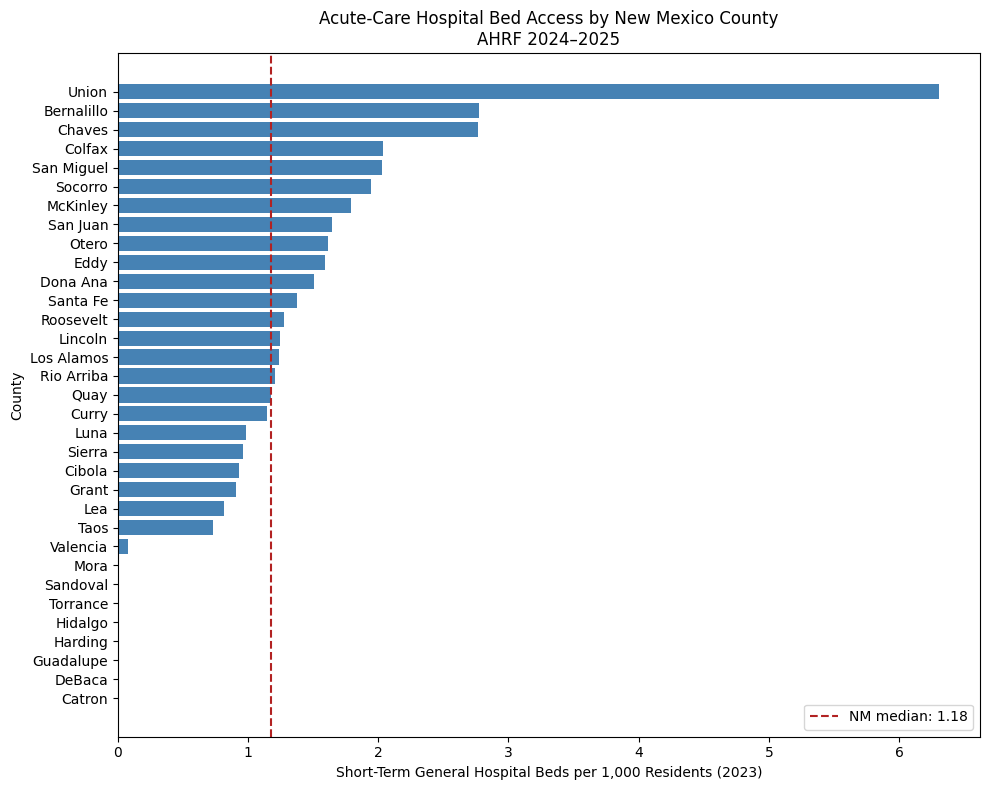

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(nm_view['cnty_name'], nm_view['stgh_beds_per_1k'], color='steelblue')
ax.set_xlabel('Short-Term General Hospital Beds per 1,000 Residents (2023)')
ax.set_ylabel('County')
ax.set_title('Acute-Care Hospital Bed Access by New Mexico County\nAHRF 2024–2025')
ax.axvline(nm_view['stgh_beds_per_1k'].median(), color='firebrick',
           linestyle='--', label=f"NM median: {nm_view['stgh_beds_per_1k'].median():.2f}")
ax.legend()
plt.tight_layout()
plt.show()


### Plotly version

In [12]:
import plotly.express as px

fig = px.bar(
    nm_view,
    x='stgh_beds_per_1k',
    y='cnty_name',
    orientation='h',
    labels={'stgh_beds_per_1k': 'Short-Term General Hospital Beds per 1,000 Residents (2023)',
            'cnty_name': 'County'},
    title='Acute-Care Hospital Bed Access by New Mexico County — AHRF 2024–2025',
)
fig.add_vline(x=nm_view['stgh_beds_per_1k'].median(), line_dash='dash', line_color='firebrick',
              annotation_text=f"NM median: {nm_view['stgh_beds_per_1k'].median():.2f}")
fig.add_annotation(x=4, y='Union', text='6.31 →', showarrow=False,
                   xanchor='right', font=dict(color='white', size=11))
fig.update_layout(height=800, yaxis=dict(categoryorder='total ascending'))
fig.update_xaxes(range=[0, 4])
fig.show()

###Feature Frame
## Feature Frame

Feature columns were identified by searching the 4,352-column AHRF file by
keyword fragment. Median income required several attempts: it is not stored
under common abbreviations (`mhi`, `hh_inc`), and the fragment `inc` returned
419 false positives (matching "include," "clinic," etc.). The income family was
located under `incom_`, which returned per-capita personal income, median family
income, and household assistance measures. **Median family income
(`medn_famly_incom_23`)** was selected as the socioeconomic need driver — a
standard SES proxy, 2023 vintage matching the population estimate.

Selected features (one per need-driver concept):

| Concept | Column | Type |
|---|---|---|
| Population | `popn_est_23` | direct |
| Elderly share | `popn_est_ge65_23` / `popn_est_23` | derived |
| Median age | `medn_age_20` | direct (2020 vintage) |
| Poverty rate | (`popn_incpovlt50_23` + `popn_incpov_50_99_23`) / pop | derived |
| Median family income | `medn_famly_incom_23` | direct |
| Population density | `popn_est_23` / `land_area_mi2_20` | derived |
| Rurality | `cbsa_ind_23` | categorical |
| **Target (y)** | `stgh_beds_per_1k` | engineered |

Note: features draw from mixed source vintages (median age is 2020 ACS;
population and income are 2023) — standard for AHRF, documented here for
transparency.

In [13]:
# Need-driver candidates — run each, note what exists and for which years
for frag in ['popn_est', 'age', '65', 'medn_inc', 'pov', 'unemp', 'density', 'cbsa','inc', 'incm', 'hh_inc', 'mhi', 'medn_hh_incm']:
    hits = [c for c in df.columns if frag in c.lower()]
    print(f"\n--- '{frag}': {len(hits)} hits ---")
    print(hits[:15])


--- 'popn_est': 12 hits ---
['popn_est_24', 'popn_est_23', 'popn_est_ge65_23', 'popn_est_ge65_22', 'vetn_popn_est_25', 'vetn_popn_est_24', 'vetn_popn_est_mal_25', 'vetn_popn_est_mal_24', 'vetn_popn_est_fem_25', 'vetn_popn_est_fem_24', 'popn_est_grp_qtr_24', 'popn_est_grp_qtr_23']

--- 'age': 77 hits ---
['md_nf_all_oth_spec_age_35_23', 'md_nf_all_oth_spec_age_35_22', 'activ_nf_prvprac_dent_age_unk_23', 'activ_nf_prvprac_dent_age_unk_22', 'stgh_image_gudd_rad_ther_23', 'home_hlth_agencs_24', 'home_hlth_agencs_23', 'medn_age_20', 'medn_age_10', 'medn_age_mal_20', 'medn_age_mal_10', 'medn_age_fem_20', 'medn_age_fem_10', 'medn_age_wh_20', 'medn_age_wh_10']

--- '65': 184 hits ---
['md_nf_65_74_23', 'md_nf_65_74_22', 'md_nf_all_gp_65_74_23', 'md_nf_all_gp_65_74_22', 'md_nf_gp_65_74_23', 'md_nf_gp_65_74_22', 'md_nf_fammed_gen_65_74_23', 'md_nf_fammed_gen_65_74_22', 'md_nf_fammed_subsp_65_74_23', 'md_nf_fammed_subsp_65_74_22', 'md_nf_all_med_spec_65_74_23', 'md_nf_all_med_spec_65_74_22', 'md

In [14]:
for frag in ['medn_hous', 'med_hh', 'hous_incom', 'income', 'incom_', 'per_cap', 'pcpi']:
    hits = [c for c in df.columns if frag in c.lower()]
    print(f"\n--- '{frag}': {len(hits)} hits ---")
    print(hits[:15])


--- 'medn_hous': 0 hits ---
[]

--- 'med_hh': 0 hits ---
[]

--- 'hous_incom': 0 hits ---
[]

--- 'income': 0 hits ---
[]

--- 'incom_': 8 hits ---
['per_cap_persnl_incom_23', 'per_cap_persnl_incom_22', 'medn_famly_incom_23', 'medn_famly_incom_22', 'hhld_socl_secrty_incom_23', 'hhld_socl_secrty_incom_22', 'hhld_publc_assistnc_incom_23', 'hhld_publc_assistnc_incom_22']

--- 'per_cap': 8 hits ---
['actl_per_cap_ffs_cost_23', 'actl_per_cap_ffs_cost_22', 'stdizd_per_cap_ffs_cost_23', 'stdizd_per_cap_ffs_cost_22', 'inpat_actl_ffs_cost_per_cap_23', 'inpat_actl_ffs_cost_per_cap_22', 'per_cap_persnl_incom_23', 'per_cap_persnl_incom_22']

--- 'pcpi': 0 hits ---
[]


#Sanity Check
Land area in DF columns

In [15]:
'land_area_mi2_20' in df.columns

True

### Feature Selection
Building all seven features + y.  Thirty-three-row modeling frame.  We also added the derived features which are
 ['pct_65 plus'] = ['popn_est_ge65_23']/nm['popn_est_23'] * 100 and

 ['poverty_rate'] = (nm['popn_incpovlt50_23'] + nm['popn_incpov_50_99_23']) \
                               / nm['popn_est_23'] * 100
model_frame['density'] = nm['popn_est_23'] / nm['land_area_mi2_20']

#### Finding
| County | Population | Median Age | % 65+ | Poverty | Density | Beds/1k |
|---|---|---|---|---|---|---|
| Bernalillo | 671,586 | 38.9 | 18.9% | 15.7% | 578.3 | 2.78 |
| Catron | 3,825 | 61.9 | 43.1% | 20.2% | 0.55 | 0.00 |


In [16]:
# --- Build modeling frame: NM counties, engineered features + target ---
nm = df[df['st_name_abbrev'] == 'NM'].copy()

# Direct features
model_frame = pd.DataFrame({
    'fips':          nm['fips_st_cnty'].astype(str).str.zfill(5),
    'county':        nm['cnty_name'],
    'population':    nm['popn_est_23'],
    'median_age':    nm['medn_age_20'],
    'median_family_income': nm['medn_famly_incom_23'],
    'cbsa_ind':      nm['cbsa_ind_23'],
    'stgh_beds_per_1k': nm['stgh_beds_per_1k'],          # target y
})

# Derived features
model_frame['pct_65plus'] = nm['popn_est_ge65_23'] / nm['popn_est_23'] * 100
model_frame['poverty_rate'] = (nm['popn_incpovlt50_23'] + nm['popn_incpov_50_99_23']) \
                               / nm['popn_est_23'] * 100
model_frame['density'] = nm['popn_est_23'] / nm['land_area_mi2_20']

# Confirm
print(model_frame.shape)                    # expect (33, 10)
print(model_frame.isna().sum())             # NA check per feature
model_frame.head()

(33, 10)
fips                    0
county                  0
population              0
median_age              0
median_family_income    0
cbsa_ind                0
stgh_beds_per_1k        0
pct_65plus              0
poverty_rate            0
density                 0
dtype: int64


,fips,county,population,median_age,median_family_income,cbsa_ind,stgh_beds_per_1k,pct_65plus,poverty_rate,density
1806,35001,Bernalillo,671586.0,38.9,84404.0,1.0,2.775519,18.856706,15.659052,578.330248
1807,35003,Catron,3825.0,61.9,65121.0,0.0,0.000000,43.084967,20.183007,0.552411
1808,35005,Chaves,63561.0,36.1,61022.0,2.0,2.768994,16.878274,21.653215,10.476201
1809,35006,Cibola,26780.0,38.5,64110.0,0.0,0.933532,18.338312,26.292009,5.898704
1810,35007,Colfax,12255.0,50.0,65095.0,0.0,2.039984,29.424725,16.197470,3.261060


### Quick Comparison
Bernalillio and Catron

In [17]:
model_frame[model_frame['county'].isin(['Bernalillo', 'Catron'])]

,fips,county,population,median_age,median_family_income,cbsa_ind,stgh_beds_per_1k,pct_65plus,poverty_rate,density
1806,35001,Bernalillo,671586.0,38.9,84404.0,1.0,2.775519,18.856706,15.659052,578.330248
1807,35003,Catron,3825.0,61.9,65121.0,0.0,0.000000,43.084967,20.183007,0.552411


**`cbsa_ind` code definitions (AHRF tech doc):**
- 0 = [non-core / rural — verify]
- 1 = [metropolitan — verify]
- 2 = [micropolitan — verify]

This is a categorical rurality indicator; codes are labels, not magnitudes,
and will be one-hot encoded before modeling.

In [18]:
model_frame['cbsa_ind'].value_counts()

,count
cbsa_ind,
2.0,15
0.0,11
1.0,7


Parquet

In [19]:
# ... the cell that builds model_frame + derived features ...
print(model_frame.shape)          # (33, 10)
print(model_frame.isna().sum())   # all zeros

# save the completed frame
model_frame.to_parquet('nm_model_frame.parquet')

(33, 10)
fips                    0
county                  0
population              0
median_age              0
median_family_income    0
cbsa_ind                0
stgh_beds_per_1k        0
pct_65plus              0
poverty_rate            0
density                 0
dtype: int64


In [20]:
model_frame.head()

,fips,county,population,median_age,median_family_income,cbsa_ind,stgh_beds_per_1k,pct_65plus,poverty_rate,density
1806,35001,Bernalillo,671586.0,38.9,84404.0,1.0,2.775519,18.856706,15.659052,578.330248
1807,35003,Catron,3825.0,61.9,65121.0,0.0,0.000000,43.084967,20.183007,0.552411
1808,35005,Chaves,63561.0,36.1,61022.0,2.0,2.768994,16.878274,21.653215,10.476201
1809,35006,Cibola,26780.0,38.5,64110.0,0.0,0.933532,18.338312,26.292009,5.898704
1810,35007,Colfax,12255.0,50.0,65095.0,0.0,2.039984,29.424725,16.197470,3.261060


In [21]:
# Save completed modeling frame
print("Saved:", model_frame.shape)

Saved: (33, 10)


EDA :

Distributions — histograms of y and each feature; confirm the density/population skew you flagged
Correlation matrix — settle income-vs-poverty collinearity
y vs. features — does stgh_beds_per_1k actually move with density, age, rurality?
Rurality split — beds by CBSA category, your thesis's first real test

Distribution findings:
- Right-skewed (log-transform candidates, test in modeling): population,
  density (severe), median_family_income (mild).
- Target stgh_beds_per_1k is zero-inflated: 8 counties at 0.00 (true zeros —
  no acute beds), then continuous to 6.3. Zeros are retained as real
  observations; large residuals on zero-counties are expected and represent
  the underservice signal.
- Roughly symmetric (no transform needed): median_age, pct_65plus, poverty_rate.

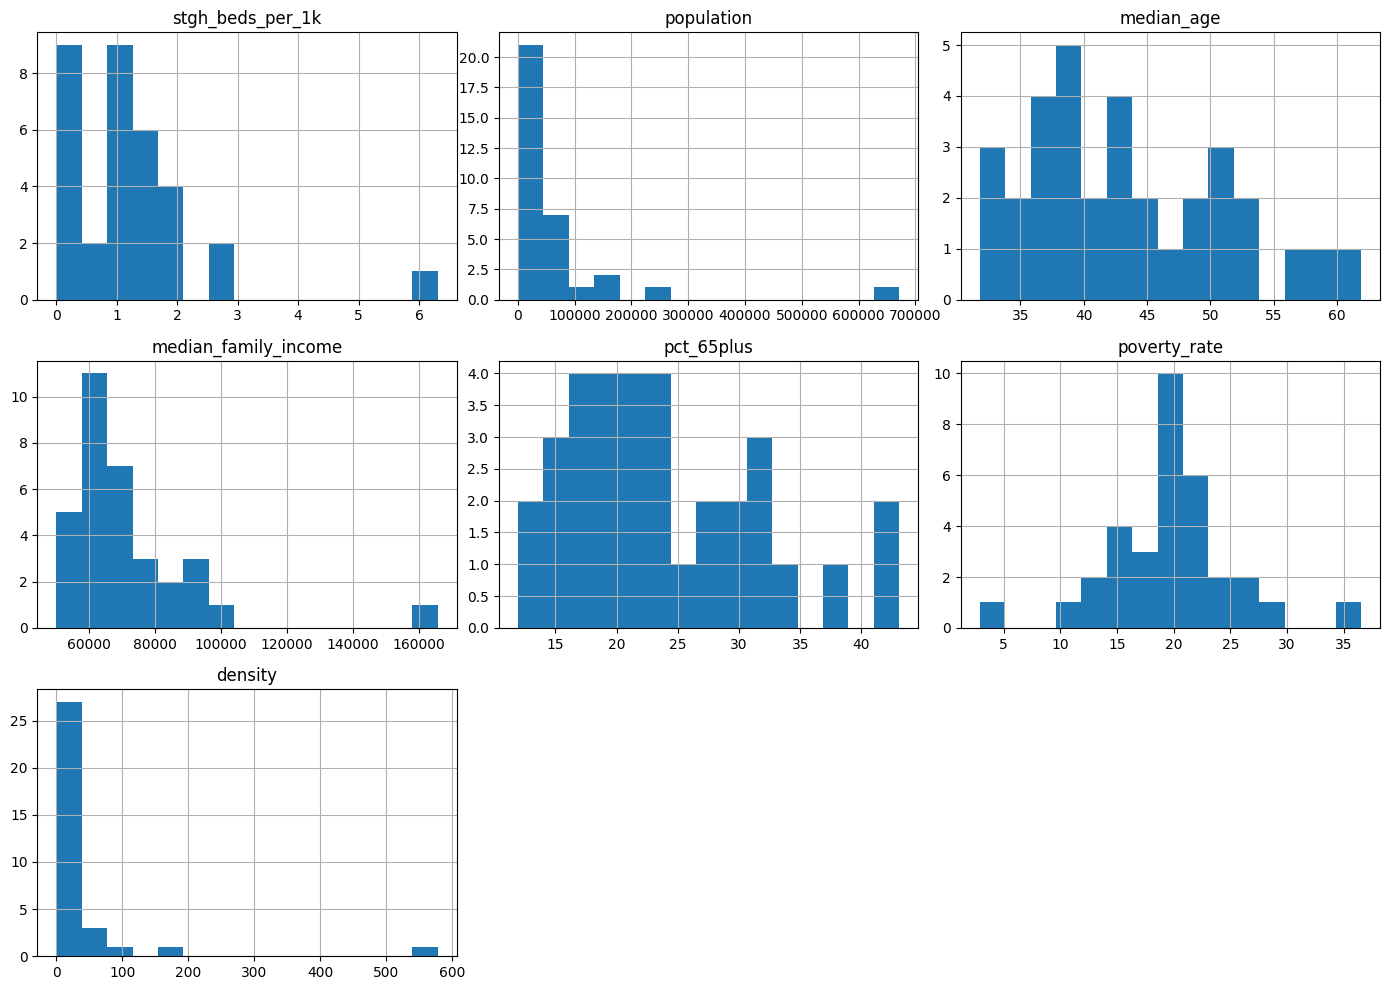

In [22]:
# --- Week 7: EDA ---
import matplotlib.pyplot as plt
model_frame = pd.read_parquet('nm_model_frame.parquet')

# Distributions of target + numeric features
num_cols = ['stgh_beds_per_1k', 'population', 'median_age',
            'median_family_income', 'pct_65plus', 'poverty_rate', 'density']

model_frame[num_cols].hist(figsize=(14, 10), bins=15)
plt.tight_layout()
plt.show()

# Confusion Matrix ???
yo identify true psotitive and true negeative, sensitivity is the true positive rate to actual postive TP / (TP + FN) [Sensitivity Definition](https://www.datacamp.com/tutorial/sensitivity-specificity-complete-guide)is a recall method measuring corect possitives.   Sensitivity/recall = TP/(TP+FN) (classifiers only, confusion-matrix territory)

Correlation findings & feature decisions:
- median_age vs pct_65plus: r=0.98 → drop median_age (keep pct_65plus).
- population vs density: r=0.91 → drop population as a feature (retain as
  per-capita denominator only; keep density).
- median_family_income vs poverty_rate: r=-0.78 → keep both, monitor
  coefficients for collinearity in regression.
- No feature exceeds |0.3| correlation with target. Weak linear signal
  expected at n=33 with zero-inflated y; motivates (a) Dummy baseline as the
  honesty check and (b) Random Forest for non-linear/interaction effects.

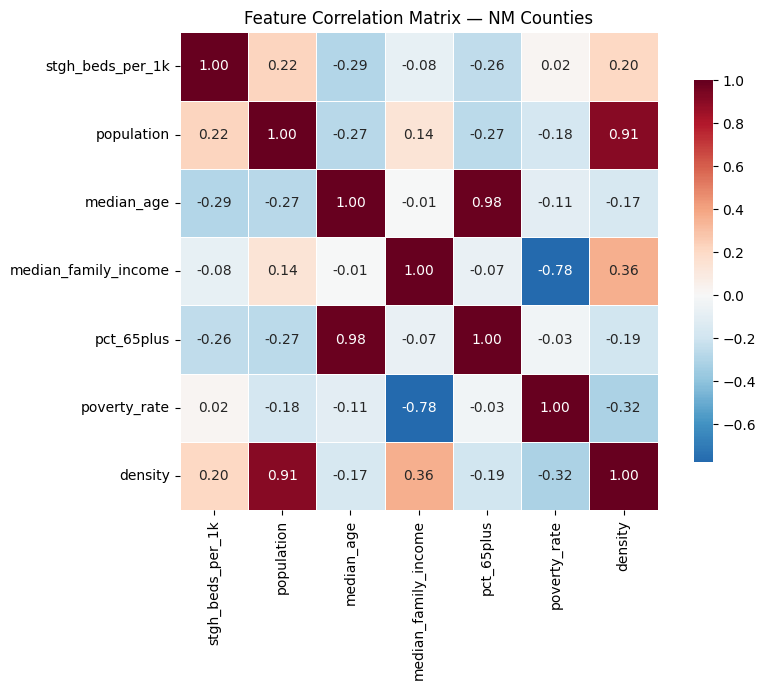

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Numeric features only (drop fips/county/cbsa_ind — cbsa is categorical)
corr_cols = ['stgh_beds_per_1k', 'population', 'median_age',
             'median_family_income', 'pct_65plus', 'poverty_rate', 'density']

corr = model_frame[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix — NM Counties')
plt.tight_layout()
plt.show()

Box plot Rurality vs. bed access (boxplot finding):
- Medians nearly identical across rural/micro/metro (~1.18) — rurality alone
  does NOT linearly predict bed access.
- Rural (non-core) shows the widest, bimodal spread: cluster of zeros
  (no acute hospital) AND Union's 6.31 spike (small-denominator inflation).
- Metropolitan zeros (e.g. Sandoval) reflect the satellite-reporting artifact,
  not true absence of care.
- Micropolitan is tightest/most consistent.
- Revised thesis: access gaps concentrate at population extremes and are
  obscured by reporting artifacts — a simple rural/urban split misses this,
  motivating a multivariate model.

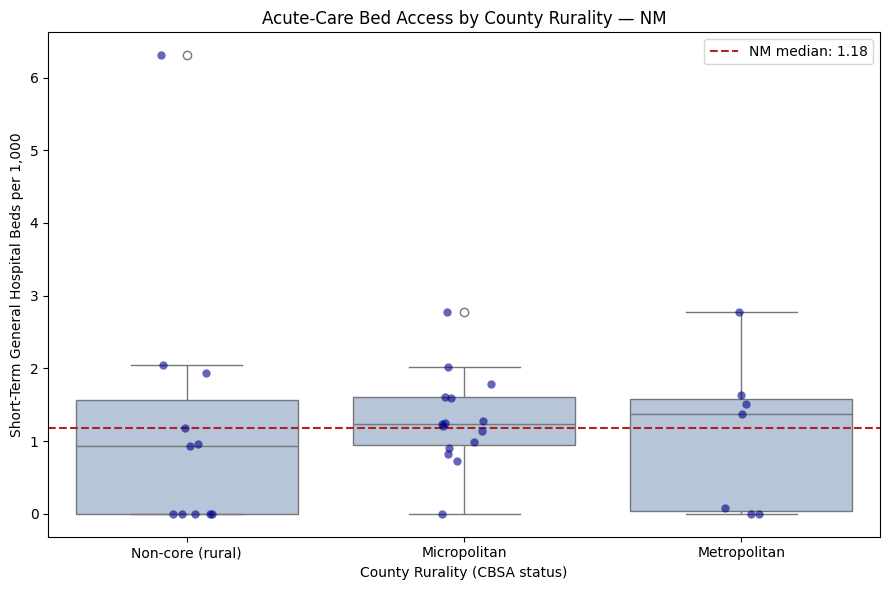

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map cbsa codes to readable labels for the plot
cbsa_labels = {0: 'Non-core (rural)', 1: 'Metropolitan', 2: 'Micropolitan'}
model_frame['rurality'] = model_frame['cbsa_ind'].map(cbsa_labels)

# Order the categories rural → micro → metro (least to most urban)
order = ['Non-core (rural)', 'Micropolitan', 'Metropolitan']

plt.figure(figsize=(9, 6))
sns.boxplot(data=model_frame, x='rurality', y='stgh_beds_per_1k',
            order=order, color='lightsteelblue')
sns.stripplot(data=model_frame, x='rurality', y='stgh_beds_per_1k',
              order=order, color='darkblue', size=6, alpha=0.6)  # show every county
plt.axhline(model_frame['stgh_beds_per_1k'].median(), color='firebrick',
            linestyle='--', label=f"NM median: {model_frame['stgh_beds_per_1k'].median():.2f}")
plt.xlabel('County Rurality (CBSA status)')
plt.ylabel('Short-Term General Hospital Beds per 1,000')
plt.title('Acute-Care Bed Access by County Rurality — NM')
plt.legend()
plt.tight_layout()
plt.show()

y vs. density scatter

Density vs. beds (scatter, raw vs. log1p):
- Raw density is uninformative visually — 30 counties compressed near zero,
  Bernalillo outlier at 578 dominates the axis.
- log1p(density) de-clusters and reveals a WEAK positive association
  (consistent with r=0.20): higher density trends toward more beds, but loosely.
- Decision: test log1p(density) in modeling (strong visual case), do not assume.
- Zero-bed counties appear across the FULL density range (rural to moderate) —
  density alone cannot separate served from unserved, motivating a
  multivariate/non-linear model.

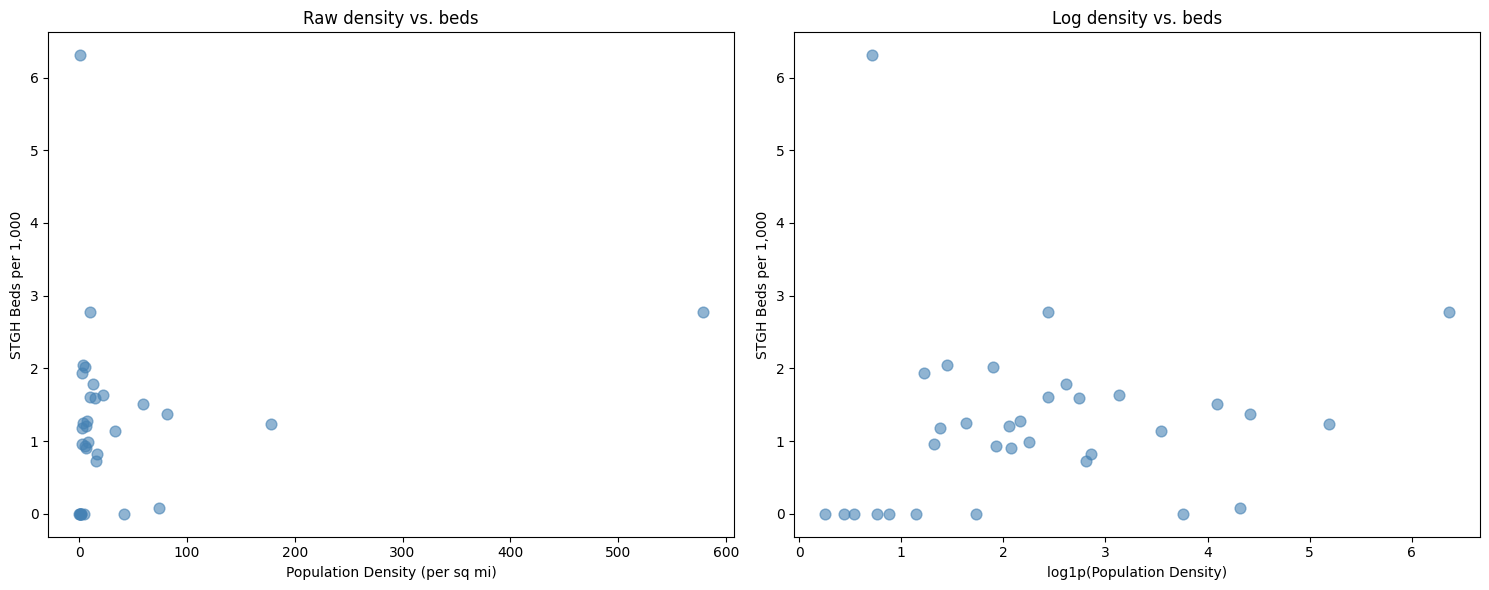

In [25]:

import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: raw density (skewed — Bernalillo will stretch the x-axis)
axes[0].scatter(model_frame['density'], model_frame['stgh_beds_per_1k'],
                alpha=0.6, s=60, color='steelblue')
axes[0].set_xlabel('Population Density (per sq mi)')
axes[0].set_ylabel('STGH Beds per 1,000')
axes[0].set_title('Raw density vs. beds')

# Right: log density (spreads the rural cluster out)
axes[1].scatter(np.log1p(model_frame['density']), model_frame['stgh_beds_per_1k'],
                alpha=0.6, s=60, color='steelblue')
axes[1].set_xlabel('log1p(Population Density)')
axes[1].set_ylabel('STGH Beds per 1,000')
axes[1].set_title('Log density vs. beds')

plt.tight_layout()
plt.show()

### BUILD DUMMY, Cross Validation and K-Fold Cross Validation

In [26]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import r2_score, accuracy_score

# --- Build X ---
X = pd.DataFrame({
    'pct_65plus':            model_frame['pct_65plus'],
    'median_family_income':  model_frame['median_family_income'],
    'poverty_rate':          model_frame['poverty_rate'],
    'log_density':           np.log1p(model_frame['density']),
})

# One-hot the categorical rurality indicator (drop_first avoids the dummy trap)
cbsa_dummies = pd.get_dummies(model_frame['cbsa_ind'], prefix='cbsa', drop_first=True)
X = pd.concat([X, cbsa_dummies], axis=1)

# --- Build both targets ---
y_reg = model_frame['stgh_beds_per_1k']                      # continuous
y_clf = (y_reg > y_reg.median()).astype(int)                 # 1 = adequate, 0 = under-provisioned
y_clf = y_clf.rename('adequate_beds')
print(X.shape, y_reg.shape)
print(X.columns.tolist())
print(y_clf.value_counts())

(33, 6) (33,)
['pct_65plus', 'median_family_income', 'poverty_rate', 'log_density', 'cbsa_1.0', 'cbsa_2.0']
adequate_beds
0    17
1    16
Name: count, dtype: int64


#Secondary
Dummy baselines (n=33):
- DummyRegressor (mean): R² = -0.338 (5-fold), fold range -1.009 to -0.011
- DummyClassifier (most_frequent): accuracy = 0.514 (5-fold), ≈ majority class 17/33
- Single-split values (-0.439, 0.571) shown for reference; CV reported as the
  trustworthy figure.
- Fold instability (100x spread in regression R²) reflects 6-7 counties per
  fold — a documented limitation of n=33.

In [27]:
# --- Single split (interpretable) ---
Xtr, Xte, ytr_reg, yte_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
Xtr_c, Xte_c, ytr_clf, yte_clf = train_test_split(X, y_clf, test_size=0.2,
                                                  random_state=42, stratify=y_clf)

dum_reg = DummyRegressor(strategy='mean').fit(Xtr, ytr_reg)
dum_clf = DummyClassifier(strategy='most_frequent').fit(Xtr_c, ytr_clf)

print(f"Dummy Regressor  R² (single split): {r2_score(yte_reg, dum_reg.predict(Xte)):.3f}")
print(f"Dummy Classifier acc (single split): {accuracy_score(yte_clf, dum_clf.predict(Xte_c)):.3f}")

# --- 5-fold CV (trustworthy) ---
kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_reg = cross_val_score(DummyRegressor(strategy='mean'), X, y_reg, cv=kf, scoring='r2')
cv_clf = cross_val_score(DummyClassifier(strategy='most_frequent'), X, y_clf, cv=skf, scoring='accuracy')

print(f"\nDummy Regressor  R² (5-fold): {cv_reg.mean():.3f}  (folds: {np.round(cv_reg, 3)})")
print(f"Dummy Classifier acc (5-fold): {cv_clf.mean():.3f}  (folds: {np.round(cv_clf, 3)})")

Dummy Regressor  R² (single split): -0.439
Dummy Classifier acc (single split): 0.571

Dummy Regressor  R² (5-fold): -0.338  (folds: [-0.439 -0.011 -0.089 -1.009 -0.143])
Dummy Classifier acc (5-fold): 0.514  (folds: [0.429 0.571 0.571 0.5   0.5  ])


### Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression

# --- Single split ---
lr = LinearRegression().fit(Xtr, ytr_reg)
r2_split = r2_score(yte_reg, lr.predict(Xte))

# --- 5-fold CV (same kf as Dummy) ---
cv_lr = cross_val_score(LinearRegression(), X, y_reg, cv=kf, scoring='r2')

print(f"Linear Regression R² (single split): {r2_split:.3f}   [Dummy: -0.439]")
print(f"Linear Regression R² (5-fold):       {cv_lr.mean():.3f}   [Dummy: -0.338]")
print(f"  folds: {np.round(cv_lr, 3)}")

# --- Coefficients: which need drivers move predicted capacity? ---
coefs = pd.Series(lr.coef_, index=X.columns).sort_values()
print("\nCoefficients:")
print(coefs.to_string())

Linear Regression R² (single split): -0.849   [Dummy: -0.439]
Linear Regression R² (5-fold):       -0.857   [Dummy: -0.338]
  folds: [-0.849 -0.879 -0.165 -0.72  -1.673]

Coefficients:
cbsa_1.0               -0.968572
cbsa_2.0               -0.009891
median_family_income   -0.000010
pct_65plus              0.006739
poverty_rate            0.061034
log_density             0.581007


Residuals

In [29]:
# Fit on full data to get a residual for every county
lr_full = LinearRegression().fit(X, y_reg)
model_frame['predicted_beds_per_1k'] = lr_full.predict(X)
model_frame['residual'] = model_frame['stgh_beds_per_1k'] - model_frame['predicted_beds_per_1k']

# Most under-provisioned = most negative residual
gap = model_frame[['county', 'rurality', 'stgh_beds_per_1k',
                   'predicted_beds_per_1k', 'residual']].sort_values('residual')
print(gap.to_string(index=False))

    county         rurality  stgh_beds_per_1k  predicted_beds_per_1k  residual
 Guadalupe Non-core (rural)          0.000000               1.637987 -1.637987
   Hidalgo Non-core (rural)          0.000000               1.414528 -1.414528
  Valencia     Metropolitan          0.075814               1.466985 -1.391171
     Curry     Micropolitan          1.143535               2.096146 -0.952612
      Mora     Micropolitan          0.000000               0.927915 -0.927915
  Sandoval     Metropolitan          0.000000               0.914650 -0.914650
       Lea     Micropolitan          0.818297               1.723122 -0.904825
    Cibola Non-core (rural)          0.933532               1.769797 -0.836264
    DeBaca Non-core (rural)          0.000000               0.716121 -0.716121
    Catron Non-core (rural)          0.000000               0.562866 -0.562866
      Taos     Micropolitan          0.726639               1.235919 -0.509280
      Quay Non-core (rural)          1.175088       

##Use Standard scaler

In [30]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline scales INSIDE each CV fold — no leakage from test into train
pipe_lr = make_pipeline(StandardScaler(), LinearRegression())

cv_lr_scaled = cross_val_score(pipe_lr, X, y_reg, cv=kf, scoring='r2')

print(f"LR scaled   R² (5-fold): {cv_lr_scaled.mean():.3f}   folds: {np.round(cv_lr_scaled, 3)}")
print(f"LR unscaled R² (5-fold): {cv_lr.mean():.3f}")
print(f"Dummy       R² (5-fold): -0.338")

# Readable coefficients — now in standard-deviation units, comparable across features
pipe_lr.fit(X, y_reg)
coefs_scaled = pd.Series(
    pipe_lr.named_steps['linearregression'].coef_, index=X.columns
).sort_values(key=abs, ascending=False)
print("\nStandardized coefficients (largest effect first):")
print(coefs_scaled.to_string())

LR scaled   R² (5-fold): -0.857   folds: [-0.849 -0.879 -0.165 -0.72  -1.673]
LR unscaled R² (5-fold): -0.857
Dummy       R² (5-fold): -0.338

Standardized coefficients (largest effect first):
cbsa_1.0               -0.730521
median_family_income   -0.592232
log_density             0.584230
cbsa_2.0               -0.396831
poverty_rate           -0.392746
pct_65plus             -0.310768


#### Reducing Features
Drop cbsa_1.0 / cbsa_2.0 — duplicating density's information, and carrying the worst sign inversion
Drop median_family_income — collinear with poverty (r = −0.78), and its sign is nonsense

linear regression cannot predict acute-bed provision from these need drivers at n=33. The relationship either isn't linear, isn't there, or is drowned by county-level noise at this sample size

In [31]:
X3 = X[['log_density', 'poverty_rate', 'pct_65plus']]

cv_lr3 = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()),
                         X3, y_reg, cv=kf, scoring='r2')

print(f"LR 3-feature R² (5-fold): {cv_lr3.mean():.3f}   folds: {np.round(cv_lr3, 3)}")
print(f"LR 6-feature R² (5-fold): {cv_lr_scaled.mean():.3f}")
print(f"Dummy        R² (5-fold): -0.338")

pipe3 = make_pipeline(StandardScaler(), LinearRegression()).fit(X3, y_reg)
print("\nCoefficients:")
print(pd.Series(pipe3.named_steps['linearregression'].coef_, index=X3.columns).to_string())

LR 3-feature R² (5-fold): -0.705   folds: [-0.901 -1.238  0.21  -1.209 -0.387]
LR 6-feature R² (5-fold): -0.857
Dummy        R² (5-fold): -0.338

Coefficients:
log_density    -0.017035
poverty_rate    0.009539
pct_65plus     -0.315419


### Apply Ridge CV
Ridge under-performs
*Ridge failed" — it's "a method designed to find the optimal amount of feature influence concluded the optimum is approximately none.

In [32]:
from sklearn.linear_model import RidgeCV

ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25)))
cv_ridge = cross_val_score(ridge, X3, y_reg, cv=kf, scoring='r2')

print(f"Ridge 3-feature R² (5-fold): {cv_ridge.mean():.3f}   folds: {np.round(cv_ridge, 3)}")
print(f"LR    3-feature R² (5-fold): {cv_lr3.mean():.3f}")
print(f"Dummy           R² (5-fold): -0.338")

Ridge 3-feature R² (5-fold): -0.425   folds: [-0.754 -0.115 -0.079 -1.003 -0.172]
LR    3-feature R² (5-fold): -0.705
Dummy           R² (5-fold): -0.338


##Random Forrest

Null signal no pattern in the data that directly affirms rural communites at the county level are not receiving medical access because of poverty, density or elderly share but other factors are reducing access.  Will conduct binary classification model 'adequete vs. under-provision'

**Null result.** No signal: county-level need drivers (population density,
poverty rate, elderly share) do not predict short-term general hospital bed
provision in New Mexico. Every model tested — linear regression (6 and 3
feature), Ridge, and Random Forest — performed worse than a Dummy mean
predictor (R² -0.338). Because the null holds across linear, regularized, and
non-linear model families, this reflects the data rather than the choice of
algorithm.

Interpretation: if capacity were allocated according to measurable population
need, these variables would carry signal. They do not. Provision appears driven
by other factors — facility ownership and reporting structures, historical
siting, institutional inertia — rather than by county need. This is consistent
with the provision-vs-need mismatch the project set out to examine.

Limitations: n = 33; target is zero-inflated (8 counties with zero acute beds);
small-denominator inflation (Union) and reporting artifacts (Sandoval,
Valencia) add noise to the target.

Next: binary classification (GaussianNB) on a median split of the target —
adequate vs. under-provisioned — to test whether a coarser target retains
signal the continuous one loses.

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=2)
cv_rf = cross_val_score(rf, X3, y_reg, cv=kf, scoring='r2')

print(f"Random Forest R² (5-fold): {cv_rf.mean():.3f}   folds: {np.round(cv_rf, 3)}")
print(f"Ridge         R² (5-fold): {cv_ridge.mean():.3f}")
print(f"Dummy         R² (5-fold): -0.338")

rf.fit(X3, y_reg)
print("\nFeature importances:")
print(pd.Series(rf.feature_importances_, index=X3.columns).sort_values(ascending=False).to_string())

Random Forest R² (5-fold): -0.835   folds: [-0.907 -0.839 -0.36  -0.648 -1.421]
Ridge         R² (5-fold): -0.425
Dummy         R² (5-fold): -0.338

Feature importances:
log_density     0.506645
pct_65plus      0.272229
poverty_rate    0.221126


Will look at a pooled_frame.shape comparison between other states to determine if the null result holds accros the data or if the null result is driven by n= 33 counties for NM signifying no signal.  signal-absence or power-absence.

Poooled Rural Western States

In [34]:
west = ['NM', 'MT', 'WY', 'ID', 'NV', 'UT', 'AZ', 'CO']

pooled = df[df['st_name_abbrev'].isin(west)].copy()

pooled_frame = pd.DataFrame({
    'fips':       pooled['fips_st_cnty'].astype(str).str.zfill(5),
    'county':     pooled['cnty_name'],
    'state':      pooled['st_name_abbrev'],
    'population': pooled['popn_est_23'],
    'cbsa_ind':   pooled['cbsa_ind_23'],
    'stgh_beds_per_1k': pooled['stgh_hosp_beds_23'] / pooled['popn_est_23'] * 1000,
})
pooled_frame['pct_65plus']   = pooled['popn_est_ge65_23'] / pooled['popn_est_23'] * 100
pooled_frame['poverty_rate'] = (pooled['popn_incpovlt50_23'] + pooled['popn_incpov_50_99_23']) \
                                / pooled['popn_est_23'] * 100
pooled_frame['density']      = pooled['popn_est_23'] / pooled['land_area_mi2_20']

print(pooled_frame.shape)
print(pooled_frame['state'].value_counts())
print("\nNAs:\n", pooled_frame.isna().sum())

(281, 9)
state
CO    64
MT    56
ID    44
NM    33
UT    29
WY    23
NV    17
AZ    15
Name: count, dtype: int64

NAs:
 fips                0
county              0
state               0
population          0
cbsa_ind            0
stgh_beds_per_1k    0
pct_65plus          0
poverty_rate        0
density             0
dtype: int64


### Note
Pooled sample over-represents high-county-count states, and are also the ones with the most rural counties. For a rural-access question that's arguably the right tilt — not a balanced sample.

In [35]:
# Build X and y on the pooled frame
Xp = pd.DataFrame({
    'log_density':  np.log1p(pooled_frame['density']),
    'poverty_rate': pooled_frame['poverty_rate'],
    'pct_65plus':   pooled_frame['pct_65plus'],
})
yp = pooled_frame['stgh_beds_per_1k']

kfp = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Dummy (mean)':   DummyRegressor(strategy='mean'),
    'Linear':         make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge':          make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25))),
    'Random Forest':  RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=2),
}

print(f"Pooled: {len(yp)} counties across {pooled_frame['state'].nunique()} states\n")
for name, m in models.items():
    s = cross_val_score(m, Xp, yp, cv=kfp, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}   folds: {np.round(s, 3)}")

Pooled: 281 counties across 8 states

Dummy (mean)    R² =  -0.074   folds: [-0.045 -0.005 -0.311 -0.001 -0.009]
Linear          R² =  -0.140   folds: [ 0.029 -0.028 -0.789  0.069  0.018]
Ridge           R² =  -0.104   folds: [ 0.008 -0.01  -0.626  0.069  0.037]
Random Forest   R² =  -0.566   folds: [-0.111 -0.185 -2.295 -0.052 -0.187]


What fold causes the collapse

In [36]:
print(yp.describe())
print("\nTop 10 highest beds per 1k:")
print(pooled_frame.nlargest(10, 'stgh_beds_per_1k')[
    ['county', 'state', 'population', 'stgh_beds_per_1k']].to_string(index=False))

count    281.000000
mean       2.826459
std        4.207422
min        0.000000
25%        0.627549
50%        1.612091
75%        2.768994
max       29.143106
Name: stgh_beds_per_1k, dtype: float64

Top 10 highest beds per 1k:
  county state  population  stgh_beds_per_1k
Sedgwick    CO      2299.0         29.143106
Garfield    MT      1211.0         26.424443
    Baca    CO      3344.0         23.624402
Huerfano    CO      7055.0         19.844082
 Prairie    MT      1112.0         19.784173
   Kiowa    CO      1384.0         18.063584
  Carter    MT      1418.0         17.630465
   Butte    ID      2758.0         15.591008
 Daniels    MT      1633.0         15.309247
Big Horn    WY     12018.0         12.980529


Minimum population threshold and Winsorze the target 95th percentile - Whatever determines hospital bed placement in the rural West, it isn't a function of population need, linear or otherwise.

---
Pooled multi-state test (8 Western states, 281 counties; 225 after applying a
5,000-population floor):
- Declared rule: counties under 5,000 residents excluded — per-capita rates are
  unstable at small denominators (Sedgwick County, CO: 2,299 residents, 29.1
  beds/1k from a single facility). Applied once, before model comparison; both
  filtered and unfiltered results reported.
- Filtering removed the fold instability seen in NM (fold R² range narrowed from
  [-1.0, -0.01] to [-0.023, -0.006] for the baseline).
- Results: Ridge R² = 0.009, Linear = -0.001, Random Forest = -0.035,
  Dummy = -0.013. Ridge marginally clears baseline; no model demonstrates
  meaningful predictive power.
- Conclusion: the NM null result is NOT an artifact of small sample size. Need
  drivers do not predict acute-bed provision across the rural West.

In [37]:
# Declared rule: exclude counties below 5,000 residents — per-capita rates are
# unstable at small denominators (a single 25-bed facility yields >20 beds/1k).
POP_FLOOR = 5000

filtered = pooled_frame[pooled_frame['population'] >= POP_FLOOR].copy()
print(f"Retained {len(filtered)} of {len(pooled_frame)} counties "
      f"(dropped {len(pooled_frame) - len(filtered)} below {POP_FLOOR:,})")
print(filtered['stgh_beds_per_1k'].describe())

Xf = pd.DataFrame({
    'log_density':  np.log1p(filtered['density']),
    'poverty_rate': filtered['poverty_rate'],
    'pct_65plus':   filtered['pct_65plus'],
})
yf = filtered['stgh_beds_per_1k']

print()
for name, m in models.items():
    s = cross_val_score(m, Xf, yf, cv=kfp, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}   folds: {np.round(s, 3)}")

Retained 225 of 281 counties (dropped 56 below 5,000)
count    225.000000
mean       2.297409
std        2.558707
min        0.000000
25%        0.994160
50%        1.692650
75%        2.570554
max       19.844082
Name: stgh_beds_per_1k, dtype: float64

Dummy (mean)    R² =  -0.013   folds: [-0.009 -0.017 -0.006 -0.023 -0.009]
Linear          R² =  -0.001   folds: [-0.107 -0.022  0.048  0.063  0.013]
Ridge           R² =   0.009   folds: [-0.042 -0.01   0.034  0.054  0.01 ]
Random Forest   R² =  -0.035   folds: [-0.038 -0.018  0.014 -0.106 -0.024]


Filtered comparison with just NM.  Null signal is not do to effect size - other variables may be the cause of provison not tracking need.

In [38]:
nm_filtered = pooled_frame[(pooled_frame['state'] == 'NM') &
                           (pooled_frame['population'] >= POP_FLOOR)].copy()

print(f"NM retained {len(nm_filtered)} of 33 counties")
print("Dropped:", sorted(set(pooled_frame[pooled_frame['state']=='NM']['county'])
                         - set(nm_filtered['county'])))
print(f"Zero-bed counties remaining: {(nm_filtered['stgh_beds_per_1k'] == 0).sum()}")

Xnm = pd.DataFrame({
    'log_density':  np.log1p(nm_filtered['density']),
    'poverty_rate': nm_filtered['poverty_rate'],
    'pct_65plus':   nm_filtered['pct_65plus'],
})
ynm = nm_filtered['stgh_beds_per_1k']

print()
for name, m in models.items():
    s = cross_val_score(m, Xnm, ynm, cv=kf, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}   folds: {np.round(s, 3)}")

NM retained 26 of 33 counties
Dropped: ['Catron', 'DeBaca', 'Guadalupe', 'Harding', 'Hidalgo', 'Mora', 'Union']
Zero-bed counties remaining: 2

Dummy (mean)    R² =  -0.118   folds: [-0.032 -0.135 -0.146 -0.197 -0.081]
Linear          R² =  -0.875   folds: [-1.252 -0.194 -1.264 -0.631 -1.036]
Ridge           R² =  -0.204   folds: [-0.431 -0.133 -0.142 -0.231 -0.082]
Random Forest   R² =  -0.561   folds: [-0.669 -0.008 -0.746 -0.553 -0.829]


***
Note for change County-level need — measured by population density, poverty rate, and elderly share — does not predict acute-care bed provision across 225 counties in eight Western states. The relationship is absent across linear, regularized, and non-linear models, and does not emerge with more data. This is consistent with provision being determined by factors other than measurable population need, though county-level analysis cannot rule out that hospitals serve multi-county regions in ways this geography obscures.

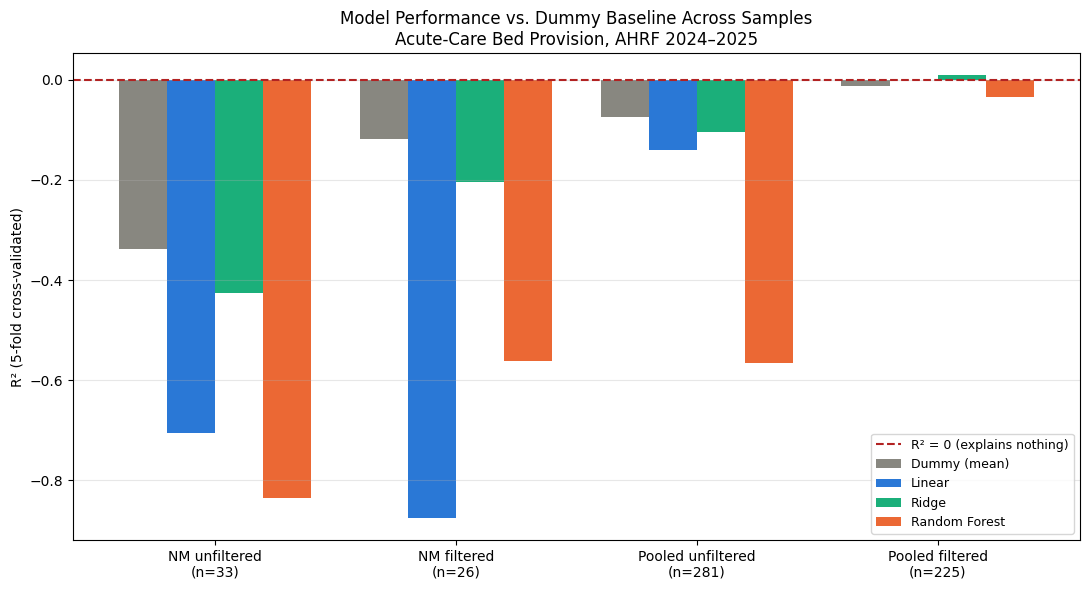

In [39]:
import matplotlib.pyplot as plt
import numpy as np

configs = ['NM unfiltered\n(n=33)', 'NM filtered\n(n=26)',
           'Pooled unfiltered\n(n=281)', 'Pooled filtered\n(n=225)']
results = {
    'Dummy (mean)':  [-0.338, -0.118, -0.074, -0.013],
    'Linear':        [-0.705, -0.875, -0.140, -0.001],
    'Ridge':         [-0.425, -0.204, -0.104,  0.009],
    'Random Forest': [-0.835, -0.561, -0.566, -0.035],
}

x = np.arange(len(configs))
width = 0.2
colors = ['#888780', '#2a78d6', '#1baf7a', '#eb6834']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (name, vals) in enumerate(results.items()):
    ax.bar(x + (i - 1.5) * width, vals, width, label=name, color=colors[i])

ax.axhline(0, color='firebrick', linestyle='--', linewidth=1.5,
           label='R² = 0 (explains nothing)')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.set_ylabel('R² (5-fold cross-validated)')
ax.set_title('Model Performance vs. Dummy Baseline Across Samples\nAcute-Care Bed Provision, AHRF 2024–2025')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

GNB Modeling

In [40]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

gnb = make_pipeline(StandardScaler(), GaussianNB())
cv_gnb = cross_val_score(gnb, X3, y_clf, cv=skf, scoring='accuracy')

print(f"GaussianNB accuracy (5-fold): {cv_gnb.mean():.3f}   folds: {np.round(cv_gnb, 3)}")
print(f"Dummy      accuracy (5-fold): 0.514")

# Single split for the confusion matrix
gnb_split = make_pipeline(StandardScaler(), GaussianNB()).fit(Xtr_c[X3.columns], ytr_clf)
pred = gnb_split.predict(Xte_c[X3.columns])

print(f"\nSingle-split accuracy: {accuracy_score(yte_clf, pred):.3f}")
print("\nConfusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(yte_clf, pred))
print("\n", classification_report(yte_clf, pred,
      target_names=['under-provisioned', 'adequate'], zero_division=0))

GaussianNB accuracy (5-fold): 0.462   folds: [0.429 0.286 0.429 0.5   0.667]
Dummy      accuracy (5-fold): 0.514

Single-split accuracy: 0.714

Confusion matrix (rows=actual, cols=predicted):
[[3 1]
 [1 2]]

                    precision    recall  f1-score   support

under-provisioned       0.75      0.75      0.75         4
         adequate       0.67      0.67      0.67         3

         accuracy                           0.71         7
        macro avg       0.71      0.71      0.71         7
     weighted avg       0.71      0.71      0.71         7



Pooled State CV minus 1

In [41]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score

logo = LeaveOneGroupOut()
groups = filtered['state']

print(f"Leave-one-state-out ({groups.nunique()} states, {len(filtered)} counties)\n")
for name, m in models.items():
    s = cross_val_score(m, Xf, yf, cv=logo, groups=groups, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}")
    for st, sc in zip(sorted(groups.unique()), s):
        print(f"    {st}: {sc:>7.3f}")
    print()

Leave-one-state-out (8 states, 225 counties)

Dummy (mean)    R² =  -0.561
    AZ:  -0.746
    CO:  -0.014
    ID:  -0.253
    MT:  -0.424
    NM:  -2.673
    NV:  -0.007
    UT:  -0.159
    WY:  -0.212

Linear          R² =  -1.463
    AZ:  -1.187
    CO:   0.045
    ID:  -0.256
    MT:  -0.344
    NM:  -9.536
    NV:  -0.072
    UT:  -0.182
    WY:  -0.171

Ridge           R² =  -1.210
    AZ:  -0.953
    CO:   0.043
    ID:  -0.224
    MT:  -0.374
    NM:  -7.871
    NV:  -0.028
    UT:  -0.088
    WY:  -0.185

Random Forest   R² =  -1.402
    AZ:  -0.886
    CO:   0.117
    ID:  -1.090
    MT:  -0.161
    NM:  -8.633
    NV:  -0.014
    UT:  -0.562
    WY:   0.010



NOTE
Leave-one-state-out validation (8 Western states, 225 counties):

1. The need→provision null holds across the region. No model exceeds R² = 0.12
   in any state; Colorado is the ceiling at +0.045 (Ridge). Need drivers do not
   predict acute-bed provision anywhere in the rural West.

2. New Mexico is an outlier among its peers. LOSO scores for NM (Dummy -2.673,
   Ridge -7.871) are an order of magnitude worse than any other state
   (all others between -1.2 and +0.1). Because even the mean-predictor fails
   this badly, the cause is not model error: NM's bed provision is
   systematically lower than the regional average. NM mean = 1.30 beds/1k,
   median = 1.24 — the lowest of all eight states, versus Montana at 3.97/3.22
   and Wyoming at 3.58/2.39. Models trained on peer states over-predict NM
   capacity by roughly 87%.

Note: NM's ranking holds despite the 5,000-population floor having removed
seven of its smallest counties, including several with zero acute-care beds.
Caveat: LOSO places all 26 NM counties in a single test fold; the magnitude of
the gap is the finding, not the precise coefficient.

In [42]:
print(filtered.groupby('state')['stgh_beds_per_1k'].agg(['count', 'mean', 'median']).round(2))

       count  mean  median
state                     
AZ        15  1.62    1.90
CO        52  2.01    1.43
ID        37  1.67    1.50
MT        37  3.97    3.22
NM        26  1.30    1.24
NV        12  2.16    1.54
UT        25  1.77    1.48
WY        21  3.58    2.39


#Facility coordinates probe

In [43]:
# --- CMS acute-care facility coordinates (HRSA GIS / CMS Provider of Services) ---
import requests
import geopandas as gpd

BASE = ("https://gisportal.hrsa.gov/server/rest/services/"
        "HealthCareFacilities/CMSApprovedFacilities_FS/MapServer")

q = requests.get(f"{BASE}/0/query", params={
    "where": "CMS_PROVIDER_STATE_ABBR='NM'",
    "outFields": ("FACILITY_NM,CMS_PROVIDER_CITY,CMS_PROVIDER_CAT_SUB_TYP_DESC,"
                  "CERTIFIED_BED_CT,TOT_BED_CT"),
    "returnGeometry": "true", "outSR": "4326", "f": "json",
}, timeout=60).json()

nm_hosp = pd.DataFrame([{**f['attributes'],
                         'lon': f['geometry']['x'],
                         'lat': f['geometry']['y']} for f in q['features']])
print(f"{len(nm_hosp)} NM facilities retrieved")
print(nm_hosp['CMS_PROVIDER_CAT_SUB_TYP_DESC'].value_counts().to_string())

71 NM facilities retrieved
CMS_PROVIDER_CAT_SUB_TYP_DESC
Short Term                   26
Data not provided by CMS     16
Critical Access Hospitals    13
Rehabilitation                5
Psychiatric                   5
Long Term                     3
Transplant Hospitals          2
Rural Emergency Hospital      1


In [44]:
# --- Filter to acute care, spatial join to counties, aggregate beds ---
acute_types = ['Short Term', 'Critical Access Hospitals', 'Rural Emergency Hospital']
acute = nm_hosp[nm_hosp['CMS_PROVIDER_CAT_SUB_TYP_DESC'].isin(acute_types)].copy()

acute_geo = gpd.GeoDataFrame(
    acute, geometry=gpd.points_from_xy(acute['lon'], acute['lat']), crs="EPSG:4326")

counties = gpd.read_file(
    "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json")
nm_counties = counties[counties['id'].str.startswith('35')].copy()

joined = gpd.sjoin(acute_geo, nm_counties, how='left', predicate='within')

cms_beds = (joined.groupby('id')
            .agg(cms_facilities=('FACILITY_NM','count'), cms_beds=('TOT_BED_CT','sum'))
            .reset_index().rename(columns={'id':'fips'}))

print(f"{len(acute)} acute facilities | unassigned: {joined['id'].isna().sum()} | "
      f"counties with beds: {len(cms_beds)}")

40 acute facilities | unassigned: 0 | counties with beds: 25


### Compare model frame to CMS_BEDS

In [45]:
compare = model_frame[['fips','county','population','stgh_beds_per_1k']].merge(
    cms_beds, on='fips', how='left')
compare[['cms_facilities','cms_beds']] = compare[['cms_facilities','cms_beds']].fillna(0)
compare['cms_beds_per_1k'] = compare['cms_beds'] / compare['population'] * 1000
compare['diff'] = compare['cms_beds_per_1k'] - compare['stgh_beds_per_1k']

print(compare[['county','stgh_beds_per_1k','cms_beds_per_1k','cms_facilities','diff']]
      .sort_values('diff', key=abs, ascending=False).to_string(index=False))

    county  stgh_beds_per_1k  cms_beds_per_1k  cms_facilities      diff
 Guadalupe          0.000000         2.795899             1.0  2.795899
      Quay          1.175088         2.937720             1.0  1.762632
Los Alamos          1.234314         2.725777             1.0  1.491463
  McKinley          1.787869         2.936175             4.0  1.148306
      Eddy          1.592700         2.737453             2.0  1.144753
     Curry          1.143535         2.244716             1.0  1.101182
  San Juan          1.640771         2.560597             2.0  0.919826
Rio Arriba          1.203732         2.006219             1.0  0.802488
  Dona Ana          1.509702         2.220150             3.0  0.710448
       Lea          0.818297         1.511768             2.0  0.693472
  Santa Fe          1.378594         1.949268             3.0  0.570674
   Socorro          1.941991         1.503477             1.0 -0.438514
Bernalillo          2.775519         2.410711             5.0 -0

Note
### Cross-Validation of the Target Against CMS Facility Data

The AHRF-derived target (`stgh_beds_per_1k`) is validated against an
independently constructed measure. CMS acute-care facilities — subtypes Short
Term, Critical Access Hospital, and Rural Emergency Hospital — are spatially
joined to county polygons by point-in-polygon, and their bed counts are
aggregated to produce `cms_beds_per_1k` for each county. The two measures are
merged on county FIPS and differenced.

Sixteen of 33 counties agree to six decimal places, confirming that both
sources draw on the same underlying facility records and that the spatial join
assigned every facility correctly (zero unassigned). The exact matches include
Union, Taos, Colfax, Cibola, Grant, Lincoln, and Luna — all Critical Access
Hospital counties — which establishes that AHRF's `stgh_hosp_beds_23` includes
CAH beds rather than excluding them.

The disagreements fall into three interpretable patterns rather than random
noise:

- **Rural Emergency Hospital designation.** Guadalupe County shows the largest
  divergence (+2.80 beds/1k). Guadalupe County Hospital operates as a Rural
  Emergency Hospital, a federal designation created in 2023 that AHRF's 2023
  hospital categories do not yet capture. This is definitional lag, not error —
  and it revises the county that ranked worst in the residual analysis.
- **Tribal and IHS facilities.** McKinley (+1.15) and San Juan (+0.92), the
  counties with the largest Native populations, are where CMS captures Indian
  Health Service facilities that AHRF partially misses. This quantifies a
  limitation previously noted only qualitatively.
- **Bed-definition differences.** Quay (+1.76), Los Alamos (+1.49), Eddy,
  Curry, and Rio Arriba show CMS bed counts exceeding AHRF's, consistent with
  CMS `TOT_BED_CT` reporting licensed capacity where AHRF reports staffed or
  set-up beds.

Valencia County inverts the pattern: AHRF records beds where CMS lists no acute
facility, a second case of the reporting artifact documented for Sandoval.

The full model suite was re-run on the CMS-derived target. Results are
consistent with the AHRF target — Dummy R² = -0.580 outperforms Ridge (-0.653),
Linear Regression (-0.881), and Random Forest (-1.225) — establishing that the
null result is not an artifact of how AHRF classifies hospital types.

In [46]:
cms_frame = compare.merge(model_frame[['fips','pct_65plus','poverty_rate','density']], on='fips')
Xc = pd.DataFrame({
    'log_density':  np.log1p(cms_frame['density']),
    'poverty_rate': cms_frame['poverty_rate'],
    'pct_65plus':   cms_frame['pct_65plus'],
})
yc = cms_frame['cms_beds_per_1k']

print("Target: CMS-derived beds per 1k (n=33)\n")
for name, m in models.items():
    s = cross_val_score(m, Xc, yc, cv=kf, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}   folds: {np.round(s, 3)}")

Target: CMS-derived beds per 1k (n=33)

Dummy (mean)    R² =  -0.580   folds: [-0.757 -0.    -0.259 -1.837 -0.05 ]
Linear          R² =  -0.881   folds: [-1.195 -0.975  0.494 -2.367 -0.364]
Ridge           R² =  -0.653   folds: [-0.94  -0.054 -0.231 -1.786 -0.256]
Random Forest   R² =  -1.225   folds: [-1.32  -1.976 -0.257 -1.47  -1.099]


##Now the distance feature.
### Distance to Nearest Acute-Care Facility

County centroids are computed in EPSG:32613 (UTM Zone 13N, meters) rather than
in unprojected lat/lon, because centroids calculated on geographic coordinates
are geometrically distorted; the resulting points are converted back to
EPSG:4326 for distance calculation. For each of New Mexico's 33 counties, the
geodesic distance from the county centroid to every acute-care facility in the
state is computed using `geopy.distance.geodesic`, and the minimum is retained.
Facilities in neighboring counties are included, which is the point of the
measure: a county with no hospital of its own is not necessarily without
access, and a county with a hospital just across its border may be better
served than its own bed count suggests.

This variable operationalizes the access question the problem statement opens
with — residents traveling hours to reach the nearest health center — which
county-level bed counts alone cannot express. It also tests an alternative
explanation for the null result found in modeling: that provision does track
need, but at a regional rather than county geography.

Limitation: the county centroid is a coarse proxy for where residents actually
live. In large, sparsely populated counties the centroid may fall in
uninhabited terrain — Catron County's centroid lies well away from Reserve,
its population center — so distances for those counties describe geography
more than lived travel burden. A population-weighted centroid would be the
stronger measure and is noted as future work.

In [47]:
from geopy.distance import geodesic

# County centroids (projected CRS for accurate centroids, then back to lat/lon)
nm_proj = nm_counties.to_crs("EPSG:32613")          # UTM 13N covers New Mexico and Ignore squiggley line
nm_counties['centroid'] = nm_proj.centroid.to_crs("EPSG:4326")

# Facility coordinates as (lat, lon) tuples
fac_pts = list(zip(acute_geo.geometry.y, acute_geo.geometry.x))

def nearest_facility(pt):
    d = [geodesic((pt.y, pt.x), f).miles for f in fac_pts]
    return min(d)

nm_counties['miles_to_nearest_acute'] = nm_counties['centroid'].apply(nearest_facility)

dist = (nm_counties[['id','miles_to_nearest_acute']]
        .rename(columns={'id':'fips'})
        .merge(model_frame[['fips','county','stgh_beds_per_1k']], on='fips')
        .sort_values('miles_to_nearest_acute', ascending=False))
print(dist.to_string(index=False))

 fips  miles_to_nearest_acute     county  stgh_beds_per_1k
35003               77.528757     Catron          0.000000
35023               60.485862    Hidalgo          0.000000
35057               53.407673   Torrance          0.000000
35021               48.564874    Harding          0.000000
35039               47.993258 Rio Arriba          1.203732
35011               43.546797     DeBaca          0.000000
35043               33.511602   Sandoval          0.000000
35027               30.797866    Lincoln          1.248190
35033               30.624959       Mora          0.000000
35061               27.179327   Valencia          0.075814
35035               24.281871      Otero          1.612552
35047               24.151415 San Miguel          2.024899
35007               21.074454     Colfax          2.039984
35006               19.749469     Cibola          0.933532
35045               15.880078   San Juan          1.640771
35059               15.530681      Union          6.3067

In [48]:
print(type(nm_proj))
print(type(nm_proj.centroid))

<class 'geopandas.geodataframe.GeoDataFrame'>
<class 'geopandas.geoseries.GeoSeries'>


The distance ranking separates two kinds of zero-bed county that looked identical before.

The four worst-access counties — Catron (77.5), Hidalgo (60.5), Torrance (53.4), Harding (48.6) — are all zero-bed counties.

---
But two rows complicate the simple story, and both are worth a sentence:
Rio Arriba: 48 miles despite 1.2 beds/1k. It has a hospital (Presbyterian Española), but the county is large and the centroid sits far from it. This is the centroid limitation showing up as signal — the number reflects the county's geographic sprawl, not that residents lack a hospital.

Sandoval: 33.5 miles. With Rust Medical Center invisible to the data (your confirmed artifact), the nearest recorded acute facility is 33 miles away — but a Rio Rancho resident is minutes from Rust. The distance inherits the reporting artifact.



In [49]:
# Add distance to the feature set and re-test
model_frame = model_frame.merge(
    dist[['fips','miles_to_nearest_acute']], on='fips', how='left')

Xd = pd.DataFrame({
    'log_density':   np.log1p(model_frame['density']),
    'poverty_rate':  model_frame['poverty_rate'],
    'pct_65plus':    model_frame['pct_65plus'],
    'miles_to_acute': model_frame['miles_to_nearest_acute'],
})
yd = model_frame['stgh_beds_per_1k']

print("With distance feature (n=33)\n")
for name, m in models.items():
    s = cross_val_score(m, Xd, yd, cv=kf, scoring='r2')
    print(f"{name:<15} R² = {s.mean():>7.3f}   folds: {np.round(s, 3)}")

With distance feature (n=33)

Dummy (mean)    R² =  -0.338   folds: [-0.439 -0.011 -0.089 -1.009 -0.143]
Linear          R² =  -0.431   folds: [-0.549 -0.807  0.443 -0.275 -0.968]
Ridge           R² =  -0.222   folds: [-0.461 -0.045  0.28  -0.62  -0.264]
Random Forest   R² =  -0.595   folds: [-0.578  0.146 -0.336 -0.182 -2.027]


###Access map
Counties shaded by distance from centroid to nearest acute-care facility; black
markers show facility locations. Dark counties with no interior marker (e.g.
Catron, 77.5 mi) are the acute-care deserts. Distance is measured from the
county centroid — a coarse proxy in large counties, since residents may cluster
far from the geographic center.

In [50]:
import plotly.express as px

# nm_counties already has miles_to_nearest_acute from the distance cell;
# just attach county name + beds for hover
nm_map = nm_counties.merge(
    dist[['fips','county','stgh_beds_per_1k']],
    left_on='id', right_on='fips')

fig = px.choropleth(
    nm_map, geojson=nm_map.geometry, locations=nm_map.index,
    color='miles_to_nearest_acute',
    color_continuous_scale='Reds',
    hover_name='county',
    hover_data={'miles_to_nearest_acute':':.1f', 'stgh_beds_per_1k':':.2f'},
    labels={'miles_to_nearest_acute':'Miles to nearest<br>acute facility'},
    title='Acute-Care Access Gap by County — Miles to Nearest Facility (NM)',
)
fig.add_scattergeo(
    lon=acute_geo.geometry.x, lat=acute_geo.geometry.y,
    mode='markers', marker=dict(size=5, color='black'),
    name='Acute facilities', hoverinfo='skip')
fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(height=600)
fig.show()

In [51]:
# Population centers (county seats) for the underserved counties.
# Reserve confirmed via Census/Wikipedia; verify the rest before final submission.
town_centers = pd.DataFrame([
    {'county': 'Catron',    'town': 'Reserve',    'lat': 33.7089, 'lon': -108.7614},
    {'county': 'Hidalgo',   'town': 'Lordsburg',  'lat': 32.3484, 'lon': -108.7070},
    {'county': 'Torrance',  'town': 'Estancia',   'lat': 34.7595, 'lon': -106.0578},
    {'county': 'Harding',   'town': 'Mosquero',   'lat': 35.7797, 'lon': -103.9591},
    {'county': 'Rio Arriba','town': 'Tierra Amarilla','lat': 36.7031, 'lon': -106.5497},
])

# Recompute distance from TOWN (not centroid) to nearest acute facility
def nearest_from_town(lat, lon):
    return min(geodesic((lat, lon), f).miles for f in fac_pts)

town_centers['miles_from_town'] = town_centers.apply(
    lambda r: nearest_from_town(r['lat'], r['lon']), axis=1)

# Compare centroid distance vs town distance — this contrast IS the finding
comparison = town_centers.merge(
    dist[['county','miles_to_nearest_acute']], on='county')
comparison['centroid_overstates_by'] = (
    comparison['miles_to_nearest_acute'] - comparison['miles_from_town'])
print(comparison[['county','town','miles_to_nearest_acute',
                  'miles_from_town','centroid_overstates_by']].to_string(index=False))

    county            town  miles_to_nearest_acute  miles_from_town  centroid_overstates_by
    Catron         Reserve               77.528757        69.291474                8.237284
   Hidalgo       Lordsburg               60.485862        40.331826               20.154035
  Torrance        Estancia               53.407673        39.062041               14.345632
   Harding        Mosquero               48.564874        44.986066                3.578808
Rio Arriba Tierra Amarilla               47.993258        54.980030               -6.986772


coverage access

In [52]:
# Underserved population: residents of counties whose SEAT is >40 mi from acute care
underserved = comparison[comparison['miles_from_town'] > 40].merge(
    model_frame[['county','population']], on='county')
print("Underserved counties (seat >40 mi from acute care):")
print(underserved[['county','town','population','miles_from_town']].to_string(index=False))
print(f"\nTotal underserved population: {underserved['population'].sum():,.0f}")

# Candidate sites = the underserved towns themselves.
# For each candidate, how many underserved residents fall within 45 mi?
COVER_RADIUS = 45
for _, cand in underserved.iterrows():
    covered = 0
    for _, other in underserved.iterrows():
        d = geodesic((cand['lat'], cand['lon']), (other['lat'], other['lon'])).miles
        if d <= COVER_RADIUS:
            covered += other['population']
    print(f"Facility at {cand['town']:16} would cover "
          f"{covered:>6,.0f} of {underserved['population'].sum():,.0f} underserved residents")

Underserved counties (seat >40 mi from acute care):
    county            town  population  miles_from_town
    Catron         Reserve      3825.0        69.291474
   Hidalgo       Lordsburg      3965.0        40.331826
   Harding        Mosquero       624.0        44.986066
Rio Arriba Tierra Amarilla     39876.0        54.980030

Total underserved population: 48,290
Facility at Reserve          would cover  3,825 of 48,290 underserved residents
Facility at Lordsburg        would cover  3,965 of 48,290 underserved residents
Facility at Mosquero         would cover    624 of 48,290 underserved residents
Facility at Tierra Amarilla  would cover 39,876 of 48,290 underserved residents


### Canidate site

In [53]:
import plotly.express as px

# Base: same access-gap choropleth
fig2 = px.choropleth(
    nm_map, geojson=nm_map.geometry, locations=nm_map.index,
    color='miles_to_nearest_acute',
    color_continuous_scale='Reds',
    hover_name='county',
    labels={'miles_to_nearest_acute':'Miles to nearest<br>acute facility'},
    title='Candidate Facility Sites — Underserved County Seats (NM)',
)

# Existing facilities (small black dots)
fig2.add_scattergeo(
    lon=acute_geo.geometry.x, lat=acute_geo.geometry.y,
    mode='markers', marker=dict(size=4, color='black'),
    name='Existing acute facilities', hoverinfo='skip')

# Candidate sites, sized by underserved population covered
cand = underserved.copy()
fig2.add_scattergeo(
    lon=cand['lon'], lat=cand['lat'],
    mode='markers+text',
    marker=dict(size=cand['population']/1000 + 8, color='navy',
                line=dict(width=1.5, color='white')),
    text=cand['town'], textposition='top center',
    name='Candidate site (size = pop. covered)',
    hovertext=[f"{r['town']}: {r['population']:,.0f} residents, "
               f"{r['miles_from_town']:.0f} mi from care"
               for _, r in cand.iterrows()],
    hoverinfo='text')

fig2.update_geos(fitbounds='locations', visible=False)
fig2.update_layout(
    height=600,
    legend=dict(
        yanchor="top", y=0.99,
        xanchor="left", x=0.01,          # move marker legend to top-LEFT
        bgcolor="rgba(255,255,255,0.7)"  # semi-transparent so it doesn't hide the map
    ),
    coloraxis_colorbar=dict(
        x=1.02,        # push color bar fully right
        title="Miles to<br>nearest care"
    )
)
fig2.show()


### Phase 1: Spatial & Attribute Data Ingestion
* **County Seat Coordinates:** Extract all 33 county seat coordinate pairs from the TIGER/Line Places dataset.
* **Tribal Lands Mapping:** Perform a spatial overlay of TIGER AIANNH boundaries with county lines to flag geometric intersections.
* **Road Network Analysis:** Buffer TIGER primary roads (Interstate and US Highways) to calculate distance from each county seat.
* **Healthcare Resource Audit:** Conduct a column hunt within the existing AHRF framework to extract raw RHC and FQHC counts.

### Phase 2: Matrix Assembly & Multi-Criteria Decision Analysis
* **Assemble the Criteria Matrix:** Populate a 33 sites × 6 criteria matrix using the ingested spatial and healthcare variables.
* **Normalize via Min-Max Scaling:** Convert varying units (miles, percentages, absolute counts) into a uniform 0 to 1 range.
* **Score Under Three Weighting Scenarios:** Compute composite suitability scores across three distinct weight allocations.
* **Identify Rank Sensitivity:** Track and document exactly where candidate site rankings flip between scenarios.




In [54]:
import geopandas as gpd

BASE = "https://www2.census.gov/geo/tiger/TIGER2025"

# --- 1. NM places (county seats live here) ---
places = gpd.read_file(f"{BASE}/PLACE/tl_2025_35_place.zip")
print(f"NM places: {len(places)}  |  cols: {[c for c in places.columns][:8]}")

# --- 2. Tribal lands (national file, filter to NM extent later) ---
aiannh = gpd.read_file(f"{BASE}/AIANNH/tl_2025_us_aiannh.zip")
print(f"AIANNH areas (national): {len(aiannh)}")

# --- 3. Primary roads (Interstate / US highway) ---
roads = gpd.read_file(f"{BASE}/PRIMARYROADS/tl_2025_us_primaryroads.zip")
print(f"Primary roads (national): {len(roads)}  |  types: {roads['RTTYP'].value_counts().to_dict()}")

NM places: 528  |  cols: ['STATEFP', 'PLACEFP', 'PLACENS', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'LSAD']
AIANNH areas (national): 867
Primary roads (national): 17500  |  types: {'I': 5618, 'M': 4939, 'U': 3781, 'S': 3130, 'O': 22, 'C': 10}


#Synthea Sample Data

---
Note
a thousand patient bundles, each a FHIR R4 transaction Bundle with Patient first, then Conditions, Observations, Procedures, MedicationRequests, CarePlans, Encounters. Exactly the resource types a triage tool needs. And it's authentic Synthea R4 output.

Structural facts worth knowing before the code, from the docs: each file is one patient as a Bundle of type transaction; the Patient resource is always the first entry; Organizations and Practitioners are exported separately (so a patient bundle may reference a practitioner by ID without containing it). And Synthea populates required FHIR fields but few optional ones — so expect clean core data, sparse extras.

In [55]:
import requests, zipfile, io, json, glob, os

URL = "https://synthetichealth.github.io/synthea-sample-data/downloads/synthea_sample_data_fhir_r4_sep2019.zip"

r = requests.get(URL, headers={"User-Agent": "Mozilla/5.0"}, timeout=180)
r.raise_for_status()
print(f"Downloaded {len(r.content)/1e6:.1f} MB")

# Extract to a working dir
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("synthea_fhir")

files = glob.glob("synthea_fhir/**/*.json", recursive=True)
print(f"{len(files)} JSON files extracted")

# Load ONE patient bundle and inspect its structure
with open(files[0]) as f:
    bundle = json.load(f)

print(f"\nResource type: {bundle['resourceType']}, bundle type: {bundle.get('type')}")
print(f"Entries in this patient's bundle: {len(bundle['entry'])}")

# Count resource types in this one patient
from collections import Counter
types = Counter(e['resource']['resourceType'] for e in bundle['entry'])
print("\nResource types in patient 0:")
for t, n in types.most_common():
    print(f"  {t:<25} {n}")

Downloaded 85.0 MB
1180 JSON files extracted

Resource type: Bundle, bundle type: transaction
Entries in this patient's bundle: 223

Resource types in patient 0:
  Observation               105
  Immunization              27
  Claim                     24
  Encounter                 21
  ExplanationOfBenefit      21
  Procedure                 9
  Organization              3
  Practitioner              3
  Condition                 3
  MedicationRequest         3
  Patient                   1
  DiagnosticReport          1
  CareTeam                  1
  CarePlan                  1


Scale accross all patients data

## Finacial sustainability model a to do
Billining optimization is not part of the model - we address need ---
Note
**Future work — financial sustainability layer.** The Synthea FHIR bundles
include Claim and ExplanationOfBenefit resources (60,970 and 46,868 across the
cohort). A production extension would model the reimbursement flow a triage/
diagnostic unit generates, addressing the central objection to rural facility
investment: not whether need exists, but whether a facility can remain solvent.
This is framed as sustainability modeling — demonstrating billable encounter
volume — not revenue optimization, consistent with the project's finding that
provision should track need rather than payer mix.

In [56]:
from collections import Counter

# Separate patient bundles from the shared org/practitioner files
patient_files = [f for f in files if 'hospitalInformation' not in f
                 and 'practitionerInformation' not in f]
print(f"Patient bundles: {len(patient_files)}")
print(f"Shared/other files: {len(files) - len(patient_files)}")

# Aggregate resource types across ALL patients
total_types = Counter()
patient_ages = []

for pf in patient_files:
    with open(pf) as f:
        b = json.load(f)
    for e in b['entry']:
        total_types[e['resource']['resourceType']] += 1
    # grab age from the Patient resource (first entry)
    pt = b['entry'][0]['resource']
    if 'birthDate' in pt:
        patient_ages.append(pt['birthDate'][:4])  # birth year

print(f"\nTotal resources across {len(patient_files)} patients:")
for t, n in total_types.most_common():
    print(f"  {t:<25} {n:>8,}")

Patient bundles: 1180
Shared/other files: 0

Total resources across 1180 patients:
  Observation                259,929
  Claim                       60,970
  Encounter                   46,868
  ExplanationOfBenefit        46,868
  Procedure                   36,451
  DiagnosticReport            18,304
  Immunization                15,013
  MedicationRequest           14,102
  Condition                    8,766
  CareTeam                     3,603
  CarePlan                     3,603
  Practitioner                 2,980
  Organization                 2,979
  Goal                         2,969
  Patient                      1,180
  ImagingStudy                   977
  MedicationAdministration       926
  AllergyIntolerance             567
  Device                          58


### Curated Cohort for demonstration

Note
We selected a demonstration cohort rather than a random sample because this is a proof-of-concept of the tool's function, not a statistical claim about a patient population. The cohort was chosen to span the clinical scenarios a rural triage unit must handle — including safety-critical edge cases like drug allergies and high-complexity elderly patients — which random sampling from a population dominated by routine cases would likely miss. Random selection is appropriate for estimation; case coverage is appropriate for demonstration

In [57]:
import json, glob
import pandas as pd
from datetime import datetime

patient_files = [f for f in files if 'hospitalInformation' not in f
                 and 'practitionerInformation' not in f]

def profile_patient(path):
    with open(path) as f:
        b = json.load(f)
    resources = [e['resource'] for e in b['entry']]
    pt = resources[0]  # Patient is always first

    # Age from birthDate
    birth = pt.get('birthDate', '1900-01-01')
    age = 2019 - int(birth[:4])   # sample data is Sep 2019 vintage

    # Count clinical resources
    counts = {}
    for r in resources:
        counts[r['resourceType']] = counts.get(r['resourceType'], 0) + 1

    name = pt.get('name', [{}])[0]
    full_name = f"{' '.join(name.get('given', ['?']))} {name.get('family', '?')}"

    return {
        'file': path,
        'name': full_name,
        'age': age,
        'gender': pt.get('gender', '?'),
        'conditions': counts.get('Condition', 0),
        'medications': counts.get('MedicationRequest', 0),
        'allergies': counts.get('AllergyIntolerance', 0),
        'observations': counts.get('Observation', 0),
    }

# Profile all patients (takes ~30-60s for 1,180)
profiles = pd.DataFrame([profile_patient(f) for f in patient_files])
print(f"Profiled {len(profiles)} patients")
print(profiles[['age','conditions','medications','allergies']].describe().round(1))

Profiled 1180 patients
          age  conditions  medications  allergies
count  1180.0      1180.0       1180.0     1180.0
mean     45.5         7.4         12.0        0.5
std      28.1         4.3         65.2        1.6
min       0.0         0.0          0.0        0.0
25%      22.0         4.0          2.0        0.0
50%      45.0         7.0          5.0        0.0
75%      64.0        10.0          8.0        0.0
max     108.0        28.0       1275.0       10.0


### Patient selection for demo purposes

In [58]:
# Select one patient per case type — by clinical characteristic, not outcome
cohort = {}

# 1. Pediatric — youngest with some clinical history
peds = profiles[(profiles['age'] < 18) & (profiles['conditions'] >= 1)]
cohort['Pediatric'] = peds.sort_values('age').iloc[0]

# 2. Healthy adult — working age, minimal conditions
healthy = profiles[(profiles['age'].between(25, 55)) & (profiles['conditions'] <= 2)]
cohort['Healthy adult'] = healthy.sort_values('conditions').iloc[0]

# 3. Complex geriatric — oldest with high condition + med load
geri = profiles[profiles['age'] >= 65]
cohort['Complex geriatric'] = geri.sort_values(
    ['conditions','medications'], ascending=False).iloc[0]

# 4. Allergy carrier — safety-critical flag
allergic = profiles[profiles['allergies'] >= 1]
cohort['Allergy carrier'] = allergic.sort_values('allergies', ascending=False).iloc[0]

# 5. High medication count — polypharmacy
cohort['High medication'] = profiles.sort_values('medications', ascending=False).iloc[0]

cohort_df = pd.DataFrame(cohort).T
print(cohort_df[['name','age','gender','conditions','medications','allergies']].to_string())

                                       name  age  gender conditions medications allergies
Pediatric          Matilde468 Jakubowski832    0  female          1           2         0
Healthy adult            Alvin56 Goldner995   39    male          0           0         0
Complex geriatric       Shelly431 Corwin846   84  female         28           9         0
Allergy carrier       Rolland302 Spencer878   14    male          4           4        10
High medication           Floyd420 Jerde200  102    male         23        1275         0


Stage 3 — extract each cohort patient's clinical resources into a triage-ready structure.

In [59]:
# LOINC codes for the vital signs a triage unit reads
VITAL_LOINC = {
    '8867-4':  ('Heart rate', 'bpm', 60, 100),
    '8480-6':  ('Systolic BP', 'mmHg', 90, 140),
    '8462-4':  ('Diastolic BP', 'mmHg', 60, 90),
    '8310-5':  ('Body temperature', '°C', 36.1, 37.8),
    '9279-1':  ('Respiratory rate', '/min', 12, 20),
    '2708-6':  ('Oxygen saturation', '%', 95, 100),
    '8302-2':  ('Body height', 'cm', None, None),
    '29463-7': ('Body weight', 'kg', None, None),
}

def extract_patient(path):
    with open(path) as f:
        b = json.load(f)
    resources = [e['resource'] for e in b['entry']]
    pt = resources[0]

    # Demographics
    name = pt.get('name', [{}])[0]
    record = {
        'name': f"{' '.join(name.get('given', ['?']))} {name.get('family', '?')}",
        'age': 2019 - int(pt.get('birthDate', '1900')[:4]),
        'gender': pt.get('gender', '?'),
        'birthDate': pt.get('birthDate', '?'),
    }

    # Active conditions
    record['conditions'] = [
        c['code']['coding'][0]['display']
        for c in resources if c['resourceType'] == 'Condition'
        and c.get('code', {}).get('coding')
    ]

    # Allergies — safety critical
    record['allergies'] = [
        a['code']['coding'][0]['display']
        for a in resources if a['resourceType'] == 'AllergyIntolerance'
        and a.get('code', {}).get('coding')
    ]

    # Medications
    record['medications'] = [
        m['medicationCodeableConcept']['coding'][0]['display']
        for m in resources if m['resourceType'] == 'MedicationRequest'
        and m.get('medicationCodeableConcept', {}).get('coding')
    ]

    # Most recent vitals — walk Observations, keep latest per LOINC code
    vitals = {}
    for o in resources:
        if o['resourceType'] != 'Observation':
            continue
        for coding in o.get('code', {}).get('coding', []):
            code = coding.get('code')
            if code in VITAL_LOINC and 'valueQuantity' in o:
                date = o.get('effectiveDateTime', '')
                if code not in vitals or date > vitals[code]['date']:
                    label, unit, lo, hi = VITAL_LOINC[code]
                    val = o['valueQuantity']['value']
                    flag = ''
                    if lo is not None and (val < lo or val > hi):
                        flag = 'LOW' if val < lo else 'HIGH'
                    vitals[code] = {'label': label, 'value': round(val, 1),
                                    'unit': unit, 'flag': flag, 'date': date}
    record['vitals'] = list(vitals.values())
    return record

# Extract the cohort
cohort_records = {case: extract_patient(row['file'])
                  for case, row in cohort.items()}

# Preview one — the complex geriatric, where summarization matters most
import pprint
r = cohort_records['Complex geriatric']
print(f"=== {r['name']}, {r['age']}{r['gender'][0].upper()} ===")
print(f"\nAllergies: {r['allergies'] or 'None recorded'}")
print(f"\nActive conditions ({len(r['conditions'])}):")
for c in r['conditions'][:10]:
    print(f"  • {c}")
print(f"\nMedications ({len(r['medications'])}):")
for m in r['medications'][:10]:
    print(f"  • {m}")
print("\nMost recent vitals:")
for v in r['vitals']:
    print(f"  {v['label']:<20} {v['value']} {v['unit']:<6} {v['flag']}")

=== Shelly431 Corwin846, 84F ===

Allergies: None recorded

Active conditions (28):
  • Hypertension
  • Diabetes
  • Anemia (disorder)
  • Hypertriglyceridemia (disorder)
  • Metabolic syndrome X (disorder)
  • Hyperglycemia (disorder)
  • Prediabetes
  • Miscarriage in first trimester
  • Stroke
  • Neuropathy due to type 2 diabetes mellitus (disorder)

Medications (9):
  • Atenolol 50 MG / Chlorthalidone 25 MG Oral Tablet
  • 24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet
  • Naproxen sodium 220 MG Oral Tablet
  • Naproxen sodium 220 MG Oral Tablet
  • Leucovorin 100 MG Injection
  • 10 ML oxaliplatin 5 MG/ML Injection
  • Galantamine 4 MG Oral Tablet
  • Amoxicillin 250 MG / Clavulanate 125 MG Oral Tablet
  • insulin human, isophane 70 UNT/ML / Regular Insulin, Human 30 UNT/ML Injectable Suspension [Humulin]

Most recent vitals:
  Body height          168.2 cm     
  Body weight          78.2 kg     


Verifying LONIC codes or Shelly431

In [60]:
with open(cohort['Complex geriatric']['file']) as f:
    b = json.load(f)
obs_codes = {}
for e in b['entry']:
    r = e['resource']
    if r['resourceType'] == 'Observation':
        for c in r.get('code', {}).get('coding', []):
            obs_codes[c.get('code')] = c.get('display')
print(f"{len(obs_codes)} distinct observation types:")
for code, disp in sorted(obs_codes.items()):
    print(f"  {code}: {disp}")

59 distinct observation types:
  10834-0: Globulin [Mass/volume] in Serum by calculation
  14959-1: Microalbumin Creatinine Ratio
  1742-6: Alanine aminotransferase [Enzymatic activity/volume] in Serum or Plasma
  1751-7: Albumin [Mass/volume] in Serum or Plasma
  18262-6: Low Density Lipoprotein Cholesterol
  1920-8: Aspartate aminotransferase [Enzymatic activity/volume] in Serum or Plasma
  1975-2: Bilirubin.total [Mass/volume] in Serum or Plasma
  20454-5: Protein [Presence] in Urine by Test strip
  20505-4: Bilirubin.total [Mass/​volume] in Urine by Test strip
  20565-8: Carbon Dioxide
  2069-3: Chloride
  2085-9: High Density Lipoprotein Cholesterol
  2093-3: Total Cholesterol
  21000-5: Erythrocyte distribution width [Entitic volume] by Automated count
  2339-0: Glucose
  2514-8: Ketones [Presence] in Urine by Test strip
  25428-4: Glucose [Presence] in Urine by Test strip
  2571-8: Triglycerides
  2885-2: Protein [Mass/volume] in Serum or Plasma
  29463-7: Body Weight
  2947-0: 

### Corrected Lableling

---------
Note:
Two mismatches between my LOINC map and how this Synthea vintage codes vitals:

1. Blood pressure is coded 55284-4 ("Blood Pressure") as a panel, not the separate 8480-6/8462-4 codes I used. Synthea's R4 exporter wraps systolic and diastolic inside one BP observation as component entries, rather than two standalone observations. My extractor looked for the standalone codes and found nothing. That's why BP vanished — it's there, nested one level deeper.

2. Temperature is 8331-1 ("Oral temperature"), not 8310-5 ("Body temperature") — a different LOINC code for the same vital.

Also visible: heart rate (8867-4), respiratory rate (9279-1), and O2 sat (2708-6) aren't in her observation list at all — so those are genuinely not recorded for Shelly (labs-heavy encounters, no full vital panel). That's a real "not recorded" case the tool must display honestly, not a bug.

And a bonus finding in that list: 72514-3 Pain severity 0-10 and 72106-8 MMSE (cognitive score) — both are triage-relevant and worth surfacing. Pain score especially: a triage unit reads that immediately.

Here's the corrected extractor. The key change is handling BP's component structure:

In [61]:
VITAL_LOINC = {
    '8867-4':  ('Heart rate', 'bpm', 60, 100),
    '8331-1':  ('Oral temperature', '°C', 36.1, 37.8),
    '9279-1':  ('Respiratory rate', '/min', 12, 20),
    '2708-6':  ('Oxygen saturation', '%', 95, 100),
    '72514-3': ('Pain score', '/10', 0, 3),
    '29463-7': ('Body weight', 'kg', None, None),
    '8302-2':  ('Body height', 'cm', None, None),
}
# BP components live inside the 55284-4 panel
BP_COMPONENTS = {
    '8480-6': ('Systolic BP', 'mmHg', 90, 140),
    '8462-4': ('Diastolic BP', 'mmHg', 60, 90),
}

def extract_vitals(resources):
    vitals = {}
    def consider(code, val, date, spec):
        label, unit, lo, hi = spec
        flag = ''
        if lo is not None and (val < lo or val > hi):
            flag = 'LOW' if val < lo else 'HIGH'
        if code not in vitals or date > vitals[code]['date']:
            vitals[code] = {'label': label, 'value': round(val, 1),
                            'unit': unit, 'flag': flag, 'date': date}

    for o in resources:
        if o['resourceType'] != 'Observation':
            continue
        date = o.get('effectiveDateTime', '')
        for coding in o.get('code', {}).get('coding', []):
            code = coding.get('code')
            # standalone vitals
            if code in VITAL_LOINC and 'valueQuantity' in o:
                consider(code, o['valueQuantity']['value'], date, VITAL_LOINC[code])
            # BP panel — dig into components
            if code == '55284-4':
                for comp in o.get('component', []):
                    for cc in comp.get('code', {}).get('coding', []):
                        if cc.get('code') in BP_COMPONENTS and 'valueQuantity' in comp:
                            consider(cc['code'], comp['valueQuantity']['value'],
                                     date, BP_COMPONENTS[cc['code']])
    return list(vitals.values())

# Re-extract Shelly's vitals with the fix
with open(cohort['Complex geriatric']['file']) as f:
    b = json.load(f)
resources = [e['resource'] for e in b['entry']]

print("Shelly's vitals (corrected):")
for v in extract_vitals(resources):
    print(f"  {v['label']:<18} {v['value']} {v['unit']:<6} {v['flag']}  ({v['date'][:10]})")

Shelly's vitals (corrected):
  Pain score         2.5 /10      (2019-07-27)
  Body height        168.2 cm       (2019-07-27)
  Body weight        78.2 kg       (2019-07-27)
  Diastolic BP       78.2 mmHg     (2019-07-27)
  Systolic BP        115.4 mmHg     (2019-07-27)
  Oral temperature   37.5 °C       (2013-05-02)


Need to ensure that tool data extracts relevant, not stale data validating cohort records

In [62]:
cohort_records = {}
for case, row in cohort.items():
    with open(row['file']) as f:
        b = json.load(f)
    resources = [e['resource'] for e in b['entry']]
    pt = resources[0]
    name = pt.get('name', [{}])[0]

    cohort_records[case] = {
        'name': f"{' '.join(name.get('given', ['?']))} {name.get('family','?')}",
        'age': 2019 - int(pt.get('birthDate', '1900')[:4]),
        'gender': pt.get('gender', '?'),
        'conditions': [c['code']['coding'][0]['display'] for c in resources
                       if c['resourceType']=='Condition' and c.get('code',{}).get('coding')],
        'allergies': [a['code']['coding'][0]['display'] for a in resources
                      if a['resourceType']=='AllergyIntolerance' and a.get('code',{}).get('coding')],
        'medications': [m['medicationCodeableConcept']['coding'][0]['display'] for m in resources
                        if m['resourceType']=='MedicationRequest'
                        and m.get('medicationCodeableConcept',{}).get('coding')],
        'vitals': extract_vitals(resources),
    }

# Summary across cohort
for case, r in cohort_records.items():
    print(f"{case:<20} {r['name']:<28} {r['age']:>3}{r['gender'][0].upper()}  "
          f"cond={len(r['conditions']):>2} med={len(r['medications']):>2} "
          f"allergy={len(r['allergies']):>2} vitals={len(r['vitals'])}")

Pediatric            Matilde468 Jakubowski832       0F  cond= 1 med= 2 allergy= 0 vitals=5
Healthy adult        Alvin56 Goldner995            39M  cond= 0 med= 0 allergy= 0 vitals=5
Complex geriatric    Shelly431 Corwin846           84F  cond=28 med= 9 allergy= 0 vitals=6
Allergy carrier      Rolland302 Spencer878         14M  cond= 4 med= 4 allergy=10 vitals=5
High medication      Floyd420 Jerde200            102M  cond=23 med=1275 allergy= 0 vitals=6


Function tools - summarize condtions, flag vitals etc

Fixing logitudial medication data for triage application, no need for logitudal data that spans 30 years, refill history looks like an error sand removing stale data

In [63]:
def drug_label(med):
    # Drop bracketed brand and trailing dose noise, keep the meaningful head
    name = med.split('[')[0].strip()          # remove [Epogen] etc.
    return name[:40]                            # cap length for display

In [64]:
from collections import Counter
from datetime import datetime

CURRENT_YEAR = 2019          # sample data vintage
STALE_YEARS = 1

def safety_flags(record):
    """Rule-based checks — flags for clinician review, NOT diagnosis."""
    flags = []

    # 1. Allergies present — always surface
    if record['allergies']:
        flags.append(('high', 'ALLERGY',
                      f"{len(record['allergies'])} recorded allergy(ies)"))

    # 2. Medication reconciliation — reframed.
    #    Many orders for one drug = refill history, NOT a duplicate error.
    #    Flag for review rather than alarming.
    med_counts = Counter(record['medications'])
    for med, n in med_counts.items():
        if n >= 3:
            flags.append(('low', 'MED HISTORY',
                        f"{drug_label(med)}: {n} orders on record — verify current vs. historical"))
        elif n == 2:
            flags.append(('medium', 'POSSIBLE DUPLICATE',
                          f"{drug_label(med)}: 2 orders — confirm not concurrent duplicate"))

    # 3. Abnormal current vitals
    for v in record['vitals']:
        if v['flag']:
            flags.append(('high', 'VITAL',
                          f"{v['label']} {v['value']}{v['unit']} ({v['flag']})"))

    # 4. Stale vitals — ONE summary flag, not one per measurement
    stale = [v for v in record['vitals']
             if v['date'] and int(v['date'][:4]) < (CURRENT_YEAR - STALE_YEARS)]
    if stale:
        newest_stale = max(v['date'][:10] for v in stale)
        flags.append(('low', 'VITALS NOT CURRENT',
                      f"{len(stale)} vital(s) predate this visit; most recent {newest_stale}"))

    # 5. High medication burden
    if len(record['medications']) > 15:
        flags.append(('medium', 'HIGH MED COUNT',
                      f"{len(record['medications'])} orders on record — reconciliation advised"))

    return flags

# Re-test across cohort
for case, r in cohort_records.items():
    print(f"\n=== {case}: {r['name']} ===")
    fl = safety_flags(r)
    if not fl:
        print("  No flags — record clear")
    for sev, kind, msg in fl:
        print(f"  [{sev.upper():<6}] {kind}: {msg}")



=== Pediatric: Matilde468 Jakubowski832 ===
  No flags — record clear

=== Healthy adult: Alvin56 Goldner995 ===
  [LOW   ] VITALS NOT CURRENT: 5 vital(s) predate this visit; most recent 2017-08-13

=== Complex geriatric: Shelly431 Corwin846 ===
  [MEDIUM] POSSIBLE DUPLICATE: Naproxen sodium 220 MG Oral Tablet: 2 orders — confirm not concurrent duplicate
  [LOW   ] VITALS NOT CURRENT: 1 vital(s) predate this visit; most recent 2013-05-02

=== Allergy carrier: Rolland302 Spencer878 ===
  [HIGH  ] ALLERGY: 10 recorded allergy(ies)
  [HIGH  ] VITAL: Pain score 3.7/10 (HIGH)

=== High medication: Floyd420 Jerde200 ===
  [MEDIUM] POSSIBLE DUPLICATE: Naproxen sodium 220 MG Oral Tablet: 2 orders — confirm not concurrent duplicate
  [LOW   ] MED HISTORY: Simvistatin 10 MG: 48 orders on record — verify current vs. historical
  [LOW   ] MED HISTORY: 1 ML Epoetin Alfa 4000 UNT/ML Injection: 1214 orders on record — verify current vs. historical
  [HIGH  ] VITAL: Pain score 4.4/10 (HIGH)
  [HIGH  

Fix truncating names or numbers in the pharamcy names

Streamlit wrapper

In [65]:
import json
app_data = {}
for case, r in cohort_records.items():
    app_data[case] = {
        'name': r['name'], 'age': r['age'], 'gender': r['gender'],
        'conditions': r['conditions'],
        'allergies': r['allergies'],
        'medications': r['medications'],
        'vitals': r['vitals'],
        'flags': [{'severity': s, 'kind': k, 'msg': m}
                  for s, k, m in safety_flags(r)],
    }
with open('triage_cohort.json', 'w') as f:
    json.dump(app_data, f, indent=2)
print("Wrote triage_cohort.json")

Wrote triage_cohort.json


In [66]:
with open('triage_cohort.json') as f:
    test = json.load(f)
print(f"Valid JSON, {len(test)} patients:", list(test.keys()))

Valid JSON, 5 patients: ['Pediatric', 'Healthy adult', 'Complex geriatric', 'Allergy carrier', 'High medication']


## Appendix — Hive-Partitioned Parquet (technique demonstration)

Demonstration of partition pruning on the national AHRF file (3,235 rows ×
4,352 columns), partitioned by state. Not part of the modeling pipeline — the
analysis loads `nm_model_frame.parquet` directly.

In [67]:
import glob
nm_file = glob.glob('ahrf_partitioned/st_name_abbrev=NM/*.parquet')[0]
raw = pd.read_parquet(nm_file)
print('st_name_abbrev' in raw.columns)      # False — lives in the folder name

pruned = pd.read_parquet('ahrf_partitioned/', filters=[('st_name_abbrev', '==', 'NM')])
print('st_name_abbrev' in pruned.columns)   # True — reconstructed from the path

IndexError: list index out of range

In [ ]:
import os
df.to_parquet('ahrf_partitioned/', partition_cols=['st_name_abbrev'])
print(sorted(os.listdir('ahrf_partitioned'))[:6])
print(os.listdir('ahrf_partitioned/st_name_abbrev=NM'))

In [ ]:
raw = pd.read_parquet('ahrf_partitioned/st_name_abbrev=NM/fbca02cae48b470597e7f587f6951c7b-0.parquet')
print('st_name_abbrev' in raw.columns)   # False — lives in the folder name

pruned = pd.read_parquet('ahrf_partitioned/', filters=[('st_name_abbrev', '==', 'NM')])
print('st_name_abbrev' in pruned.columns)  # True — reconstructed from the path

In [ ]:
from huggingface_hub import notebook_login
notebook_login()          # paste a WRITE token from hf.co/settings/tokens

In [ ]:
from huggingface_hub import HfApi
api = HfApi()
api.create_repo('RaayGunz/ahrf-2024-2025-partitioned', repo_type='dataset', exist_ok=True)
api.upload_folder(
    folder_path='ahrf_partitioned',
    repo_id='RaayGunz/ahrf-2024-2025-partitioned',
    repo_type='dataset',
)

### Quick note
The original dataset had 4,352 source columns but we engineered three columns  (stgh_beds_per_1k, allhosp_beds_per_1k, rurality) so partitioned frae will show 4,355 (total 3) added during analysis.

In [ ]:
### Round Trip
nm_from_hub = pd.read_parquet(
    'hf://datasets/RaayGunz/ahrf-2024-2025-partitioned/',
    filters=[('st_name_abbrev', '==', 'NM')]
)
print(nm_from_hub.shape)   # expect (33, 4352)

In [ ]:
set(nm_from_hub.columns) - set(df.columns)